# 🎬 YouTube Data Dashboard — Jupyter Notebook

<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);padding:20px;border-radius:12px;border-left:6px solid #ff0000;">
<h3 style="color:#ff4444;margin:0">Project 3 — Building a YouTube Data Dashboard</h3>
<p style="color:#a8dadc;margin-top:8px;font-size:0.95rem">
Analyze and visualize key YouTube channel metrics including video views, watch time,
subscriber growth, engagement rates, revenue, and audience demographics.
</p>
</div>

---

## 📋 Notebook Workflow

| Step | Section | Key Output |
|------|---------|------------|
| 1 | Setup & Imports | Libraries configured |
| 2 | Data Generation / API Load | Channel + Video + Time-series data |
| 3 | Data Cleaning & Preprocessing | Clean dataset + derived features |
| 4 | Channel Overview & KPIs | Summary statistics |
| 5 | Subscriber Growth Analysis | Trend charts |
| 6 | Video Performance Analysis | Top videos, engagement |
| 7 | Watch Time & Retention | Duration analysis |
| 8 | Engagement Deep Dive | Likes, comments, CTR |
| 9 | Revenue Analysis | RPM, revenue trends |
| 10 | Audience Demographics | Age, gender, geography |
| 11 | Traffic Sources & Devices | Discovery patterns |
| 12 | Correlation Analysis | Feature relationships |
| 13 | Summary Dashboard | All-in-one visual |
| 14 | Insights & Recommendations | Actionable findings |

---

## Step 1 — Setup & Library Import

In [1]:
# ── Core ─────────────────────────────────────────────────────
import numpy             as np
import pandas            as pd
from   datetime          import datetime, timedelta
from   scipy             import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot        as plt
import matplotlib.gridspec      as gridspec
import matplotlib.ticker        as mticker
import matplotlib.dates         as mdates
import matplotlib.patches       as mpatches
from   matplotlib.patches       import FancyBboxPatch
import seaborn                  as sns

# ── Notebook display ─────────────────────────────────────────
from IPython.display import display, HTML

# ── Global Style ─────────────────────────────────────────────
DARK_BG   = '#0f0f1a'
CARD_BG   = '#1e1e3a'
ACCENT    = '#ff4444'
C_VIEWS   = '#2196F3'
C_SUBS    = '#4CAF50'
C_WATCH   = '#FF9800'
C_REV     = '#9C27B0'
C_ENGAGE  = '#00BCD4'
C_DEATHS  = '#F44336'
PALETTE   = [ACCENT,'#FF9800','#FFEB3B','#4CAF50',
             '#2196F3','#9C27B0','#00BCD4','#E91E63']

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : CARD_BG,
    'axes.edgecolor'   : '#3a3a6e',
    'axes.labelcolor'  : '#cccccc',
    'axes.titlecolor'  : '#ffffff',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.color'      : '#aaaaaa',
    'ytick.color'      : '#aaaaaa',
    'grid.color'       : '#2a2a4a',
    'grid.alpha'       : 0.5,
    'text.color'       : '#e0e0e0',
    'legend.facecolor' : CARD_BG,
    'legend.edgecolor' : '#3a3a6e',
    'legend.labelcolor': '#cccccc',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
})
sns.set_palette(PALETTE)

SEED = 42
np.random.seed(SEED)

# ── Utility: number formatter ─────────────────────────────────
def fmt(n):
    if   n >= 1_000_000_000: return f"{n/1e9:.2f}B"
    elif n >= 1_000_000:     return f"{n/1e6:.2f}M"
    elif n >= 1_000:         return f"{n/1e3:.1f}K"
    return str(int(n))

print('✅  All libraries loaded!')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅  All libraries loaded!
   NumPy  : 2.1.3
   Pandas : 2.2.3


---
## Step 2 — Data Loading
> **To use real YouTube API:**
> 1. Get an API key at https://console.cloud.google.com/ → YouTube Data API v3  
> 2. Install: `pip install google-api-python-client`  
> 3. Replace `CHANNEL_NAME` and `API_KEY` below and uncomment the API block.

# ══════════════════════════════════════════════════════════════
#  CONFIGURATION — Change these values
# ══════════════════════════════════════════════════════════════

In [3]:
CHANNEL_NAME = "TechVision"          # Your channel name (demo)
API_KEY      = ""                    # Paste your YouTube API key here
CHANNEL_ID   = ""                    # Paste your Channel ID here
USE_REAL_API = bool(API_KEY and CHANNEL_ID)

print(f'Mode: {"🔑 Real YouTube API" if USE_REAL_API else "📊 Simulated Demo Data"}')

Mode: 📊 Simulated Demo Data


# ══════════════════════════════════════════════════════════════
#  SIMULATED DATA GENERATOR
# ══════════════════════════════════════════════════════════════

In [4]:
COUNTRIES_LIST = [
    ('United States',38),('India',18),('United Kingdom',9),
    ('Canada',7),('Australia',5),('Germany',4),
    ('Brazil',4),('France',3),('Japan',3),('Mexico',2),
    ('Others',7),
]

CATEGORIES = ['Tutorial','Review','News','Vlog',
              'Short','Live','Interview']

TAGS_POOL  = ['Python','AI','Tech','Review','Tips','2024',
              'Beginner','Advanced','How-to','Best']

TODAY      = datetime(2024, 3, 31)

def make_dataset(channel_name=CHANNEL_NAME, seed=SEED):
    rng = np.random.default_rng(seed)

    # ── Channel metadata ──────────────────────────────────────
    channel = {
        'name'         : channel_name,
        'handle'       : f'@{channel_name.lower().replace(" ","")}',
        'subscribers'  : 2_480_000,
        'total_views'  : 345_600_000,
        'total_videos' : 312,
        'joined_date'  : 'Jan 15, 2017',
        'country'      : 'United States',
        'category'     : 'Science & Technology',
    }

    # ── 150 videos ────────────────────────────────────────────
    records = []
    for i in range(150):
        days_ago   = int(rng.integers(1, 1095))
        pub_date   = TODAY - timedelta(days=days_ago)
        cat        = rng.choice(CATEGORIES,
                                p=[0.30,0.20,0.15,0.10,0.10,0.10,0.05])
        is_short   = (cat == 'Short')
        dur_sec    = int(rng.integers(45, 65) if is_short
                        else rng.integers(180, 3600))
        views      = int(rng.lognormal(10.5, 1.8))
        likes      = int(views * rng.uniform(0.03, 0.12))
        comments   = int(views * rng.uniform(0.002, 0.025))
        shares     = int(views * rng.uniform(0.001, 0.015))
        dislikes   = int(likes * rng.uniform(0.01, 0.08))
        watch_pct  = round(float(rng.uniform(28, 78)), 1)
        ctr        = round(float(rng.uniform(3, 14)), 2)
        rpm        = round(float(rng.uniform(0.8, 6.5)), 2)
        revenue    = round(views / 1000 * rpm, 2)
        impressions= int(views / (ctr / 100))
        suffixes   = ['Deep Dive','Quick Guide','Best Of',
                      'vs','Complete Review','Tutorial',
                      'Ultimate Guide','for Beginners']
        records.append({
            'video_id'     : f'vid_{i:03d}',
            'title'        : f"{cat} #{i+1}: {rng.choice(suffixes)}",
            'category'     : cat,
            'published_at' : pub_date,
            'duration_sec' : dur_sec,
            'views'        : views,
            'likes'        : likes,
            'dislikes'     : dislikes,
            'comments'     : comments,
            'shares'       : shares,
            'watch_pct'    : watch_pct,
            'ctr_pct'      : ctr,
            'impressions'  : impressions,
            'rpm'          : rpm,
            'revenue_usd'  : revenue,
            'tags'         : ', '.join(rng.choice(TAGS_POOL, 3, replace=False)),
        })

    videos = pd.DataFrame(records)
    videos['engagement_rate'] = (
        (videos['likes'] + videos['comments']) / videos['views'] * 100
    ).round(3)
    videos['duration_min']    = (videos['duration_sec'] / 60).round(1)
    videos['watch_hours']     = (
        videos['views'] * videos['watch_pct'] / 100
        * videos['duration_sec'] / 3600
    ).round(0).astype(int)
    videos['like_ratio']      = (videos['likes'] /
                                  (videos['likes'] + videos['dislikes'].replace(0,1))
                                  * 100).round(1)
    videos = videos.sort_values('published_at', ascending=False).reset_index(drop=True)

    # ── 365-day time series ───────────────────────────────────
    days = pd.date_range(TODAY - timedelta(days=364), TODAY, freq='D')
    n    = len(days)
    t    = np.linspace(0, 1, n)

    trend    = np.linspace(4000, 14000, n)
    seasonal = 2800 * np.sin(2 * np.pi * t * 3.5)
    spikes   = np.zeros(n)
    for sp in rng.choice(n, 10, replace=False):
        spikes[sp] = float(rng.uniform(8000, 35000))
    noise    = rng.normal(0, 700, n)
    daily_v  = np.clip(trend + seasonal + spikes + noise, 300, None).astype(int)

    subs_gain = np.clip(
        daily_v / 110 + rng.normal(0, 10, n), 0, None
    ).astype(int)
    subs_lost = np.clip(rng.poisson(14, n), 0, None)
    net_subs  = subs_gain - subs_lost
    subs_cum  = 2_100_000 + np.cumsum(net_subs)
    watch_hrs = (daily_v * rng.uniform(3, 7, n)).astype(int)
    revenue_d = (daily_v / 1000 * rng.uniform(1.5, 5.0, n)).round(2)
    impress   = (daily_v * rng.uniform(5, 16, n)).astype(int)

    ts = pd.DataFrame({
        'date'          : days,
        'views'         : daily_v,
        'watch_hours'   : watch_hrs,
        'subs_gained'   : subs_gain,
        'subs_lost'     : subs_lost,
        'net_subs'      : net_subs,
        'subscribers'   : subs_cum,
        'revenue_usd'   : revenue_d,
        'impressions'   : impress,
    })
    ts['ctr_pct']       = (ts['views'] / ts['impressions'] * 100).round(2)
    ts['avg_view_dur']  = rng.uniform(160, 440, n).round(0)
    ts['engagement_r']  = rng.uniform(4.5, 9.8, n).round(2)

    # ── Demographics ─────────────────────────────────────────
    demo = {
        'age'   : pd.DataFrame({'group':['13-17','18-24','25-34',
                                          '35-44','45-54','55-64','65+'],
                                 'pct'  :[4,22,31,20,13,7,3]}),
        'gender': {'Male':62,'Female':35,'Other':3},
        'geo'   : pd.DataFrame(COUNTRIES_LIST, columns=['country','pct']),
        'traffic': pd.DataFrame({
            'source':['YouTube Search','Suggested Videos','External',
                      'Browse Features','Channel Pages','Playlists','Other'],
            'pct'   :[32,28,15,10,7,5,3],
        }),
        'devices': pd.DataFrame({
            'device':['Mobile','Desktop','TV','Tablet'],
            'pct'   :[62,22,11,5],
        }),
    }
    return channel, videos, ts, demo


# ── Real API loader (optional) ────────────────────────────────
def load_from_api(api_key, channel_id):
    try:
        from googleapiclient.discovery import build
    except ImportError:
        print('❌  Run: pip install google-api-python-client')
        return None
    yt    = build('youtube','v3', developerKey=api_key)
    ch    = yt.channels().list(
        part='snippet,statistics,contentDetails', id=channel_id
    ).execute()['items'][0]
    ch_sn = ch['snippet']; ch_st = ch['statistics']
    channel = {
        'name'        : ch_sn['title'],
        'handle'      : ch_sn.get('customUrl',''),
        'subscribers' : int(ch_st.get('subscriberCount',0)),
        'total_views' : int(ch_st.get('viewCount',0)),
        'total_videos': int(ch_st.get('videoCount',0)),
        'joined_date' : ch_sn['publishedAt'][:10],
        'country'     : ch_sn.get('country','N/A'),
        'category'    : 'YouTube Channel',
    }
    uploads = ch['contentDetails']['relatedPlaylists']['uploads']
    pl = yt.playlistItems().list(
        part='contentDetails', playlistId=uploads, maxResults=50
    ).execute()
    ids = [i['contentDetails']['videoId'] for i in pl['items']]
    vr  = yt.videos().list(
        part='snippet,statistics', id=','.join(ids)
    ).execute()
    rows = []
    for item in vr['items']:
        sn = item['snippet']; st = item['statistics']
        v  = int(st.get('viewCount',0))
        l  = int(st.get('likeCount',0))
        c  = int(st.get('commentCount',0))
        rows.append({'video_id':item['id'],'title':sn['title'],
                     'category':sn.get('categoryId','N/A'),
                     'published_at':pd.to_datetime(sn['publishedAt']),
                     'views':v,'likes':l,'comments':c,
                     'dislikes':0,'shares':0,'duration_sec':0,
                     'watch_pct':50,'ctr_pct':0,'impressions':0,
                     'rpm':0,'revenue_usd':0,'tags':'',
                     'engagement_rate':round((l+c)/max(v,1)*100,3),
                     'duration_min':0,'watch_hours':0,'like_ratio':0})
    videos = pd.DataFrame(rows)
    return channel, videos, pd.DataFrame(), {}


# ── Load ──────────────────────────────────────────────────────
if USE_REAL_API:
    result = load_from_api(API_KEY, CHANNEL_ID)
    if result:
        channel, videos, ts, demo = result
    else:
        print('Falling back to demo data.')
        channel, videos, ts, demo = make_dataset()
else:
    channel, videos, ts, demo = make_dataset()

print(f'✅  Channel  : {channel["name"]}  ({fmt(channel["subscribers"])} subscribers)')
print(f'   Videos   : {len(videos)} loaded')
print(f'   TS rows  : {len(ts)} days')
print(f'   Date range: {ts["date"].min().date()} → {ts["date"].max().date()}')

✅  Channel  : TechVision  (2.48M subscribers)
   Videos   : 150 loaded
   TS rows  : 365 days
   Date range: 2023-04-02 → 2024-03-31


---
## Step 3 — Data Cleaning & Preprocessing

In [5]:
# ── 3.1 Missing values ────────────────────────────────────────
print('── Missing Value Report ──────────────────────────────')
for df_name, df_ in [('videos', videos), ('time_series', ts)]:
    m = df_.isnull().sum()
    m = m[m > 0]
    if m.empty:
        print(f'  {df_name:15s}: ✅  No missing values')
    else:
        print(f'  {df_name:15s}: ⚠️  {m.to_dict()}')
        if df_name == 'videos':
            videos.fillna({'views':0,'likes':0,'comments':0,
                           'watch_hours':0,'revenue_usd':0}, inplace=True)
        ts.fillna(method='ffill', inplace=True)
        ts.fillna(0, inplace=True)

# ── 3.2 Duplicates ────────────────────────────────────────────
dupes = videos.duplicated('video_id').sum()
print(f'\n  Duplicate videos : {dupes}')
videos.drop_duplicates('video_id', inplace=True)

# ── 3.3 Feature engineering — videos ─────────────────────────
videos['pub_year']    = videos['published_at'].dt.year
videos['pub_month']   = videos['published_at'].dt.month
videos['pub_weekday'] = videos['published_at'].dt.day_name()
videos['pub_hour']    = videos['published_at'].dt.hour
videos['age_days']    = (TODAY - videos['published_at']).dt.days
videos['views_per_day'] = (videos['views'] / videos['age_days'].replace(0,1)).round(1)
videos['dur_band'] = pd.cut(
    videos['duration_min'],
    bins  =[0,1,5,10,20,60,9999],
    labels=['<1 min','1-5 min','5-10 min','10-20 min','20-60 min','>60 min']
)

# ── 3.4 Feature engineering — time series ────────────────────
ts = ts.sort_values('date').reset_index(drop=True)
ts['views_7d']   = ts['views'].rolling(7).mean()
ts['views_30d']  = ts['views'].rolling(30).mean()
ts['watch_7d']   = ts['watch_hours'].rolling(7).mean()
ts['rev_7d']     = ts['revenue_usd'].rolling(7).mean()
ts['month']      = ts['date'].dt.to_period('M').astype(str)
ts['weekday']    = ts['date'].dt.day_name()
ts['week']       = ts['date'].dt.isocalendar().week.astype(int)

print('\n✅  Preprocessing complete!')
print(f'   Videos  shape: {videos.shape}')
print(f'   TS      shape: {ts.shape}')
print(f'   New video columns  : age_days, views_per_day, dur_band, pub_year/month/weekday/hour')
print(f'   New ts columns     : views_7d, views_30d, watch_7d, rev_7d, month, weekday, week')

── Missing Value Report ──────────────────────────────
  videos         : ✅  No missing values
  time_series    : ✅  No missing values

  Duplicate videos : 0

✅  Preprocessing complete!
   Videos  shape: (150, 27)
   TS      shape: (365, 19)
   New video columns  : age_days, views_per_day, dur_band, pub_year/month/weekday/hour
   New ts columns     : views_7d, views_30d, watch_7d, rev_7d, month, weekday, week


In [6]:
print('── Video Dataset Sample ──────────────────────────────')
videos[['title','category','published_at','views','likes',
        'engagement_rate','watch_hours','revenue_usd']].head(8)

── Video Dataset Sample ──────────────────────────────


,title,category,published_at,views,likes,engagement_rate,watch_hours,revenue_usd
0,News #55: Best Of,News,2024-03-29,72974,7337,11.262,14358,433.47
1,Review #28: Tutorial,Review,2024-03-22,62809,6202,11.912,27814,92.33
2,Vlog #50: Complete Review,Vlog,2024-03-22,131252,4515,4.179,32273,611.63
3,Tutorial #46: Complete Review,Tutorial,2024-03-21,27245,3091,12.575,2876,131.05
4,Vlog #35: Best Of,Vlog,2024-03-13,804025,68373,8.829,178183,1439.20
5,Vlog #15: for Beginners,Vlog,2024-03-06,266018,10242,5.768,83352,1473.74
6,Tutorial #40: vs,Tutorial,2024-02-14,256149,8965,4.345,17910,225.41
7,Tutorial #32: Quick Guide,Tutorial,2024-02-11,83024,3285,6.454,23880,80.53


In [7]:
# ── Descriptive Statistics ────────────────────────────────────
print('── Descriptive Statistics ────────────────────────────')
key_cols = ['views','likes','comments','watch_hours',
            'engagement_rate','revenue_usd','duration_min']
videos[key_cols].describe().T.style \
    .background_gradient(cmap='YlOrRd', axis=1) \
    .format(precision=2)

── Descriptive Statistics ────────────────────────────


,count,mean,std,min,25%,50%,75%,max
views,150.00,160451.23,427546.48,208.00,11314.25,39407.00,99818.25,3897370.00
likes,150.00,11054.35,30855.89,14.00,842.75,3103.50,7679.50,296771.00
comments,150.00,2469.81,7870.82,2.00,124.50,466.50,1794.25,73832.00
watch_hours,150.00,46663.66,136482.53,11.00,1101.00,6583.50,28607.50,1082210.00
engagement_rate,150.00,9.07,2.68,3.54,6.81,9.06,11.34,14.34
revenue_usd,150.00,718.93,2188.05,1.09,32.94,125.38,394.13,20889.90
duration_min,150.00,28.94,18.17,0.80,13.03,28.10,45.12,59.60


---
## Step 4 — Channel Overview & KPIs

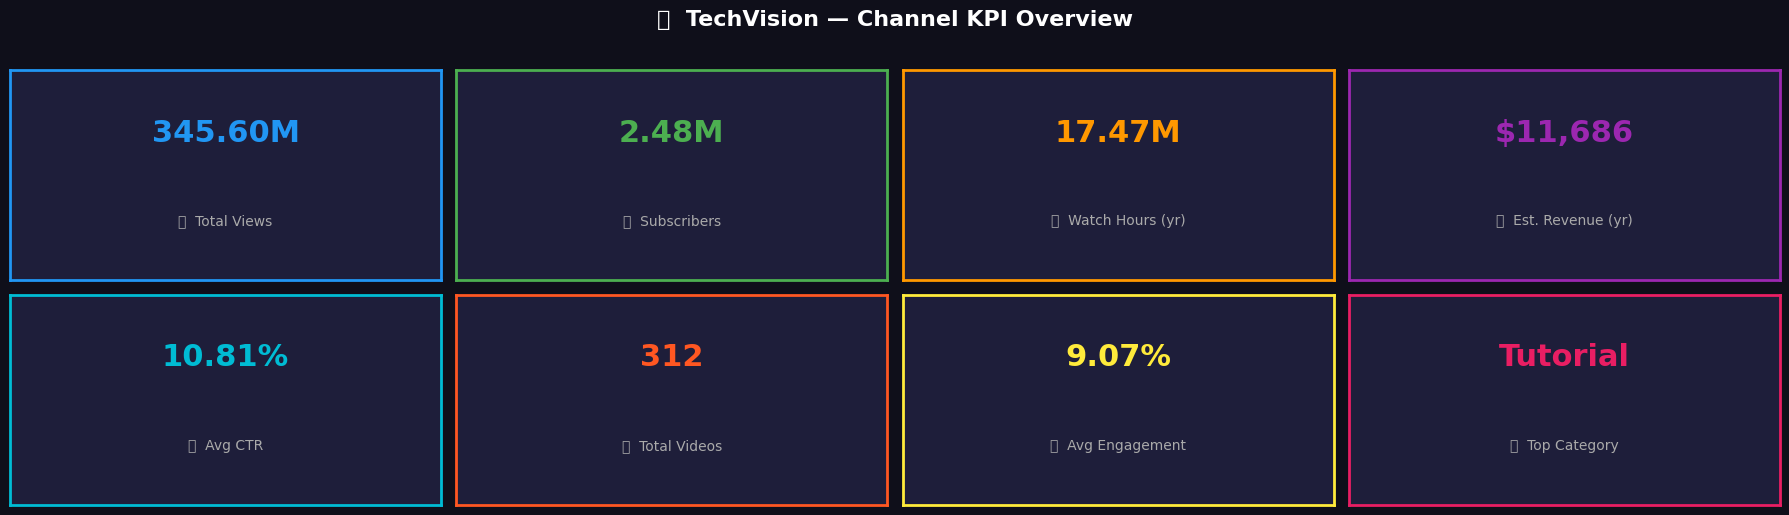

💾  Saved: yt_01_kpi_cards.png


In [8]:
# ── KPI Summary Card Display ──────────────────────────────────
period_views = int(ts['views'].sum())
period_watch = int(ts['watch_hours'].sum())
period_rev   = ts['revenue_usd'].sum()
period_subs  = int(ts['net_subs'].sum())
avg_ctr      = ts['ctr_pct'].mean()
avg_dur      = ts['avg_view_dur'].mean()
top_cat      = videos['category'].value_counts().index[0]
avg_engage   = videos['engagement_rate'].mean()

kpis = [
    ('👁️  Total Views',      fmt(channel['total_views']),  C_VIEWS),
    ('📺  Subscribers',       fmt(channel['subscribers']),  C_SUBS),
    ('⏱️  Watch Hours (yr)', fmt(period_watch),             C_WATCH),
    ('💰  Est. Revenue (yr)', f'${period_rev:,.0f}',        C_REV),
    ('🖱️  Avg CTR',          f'{avg_ctr:.2f}%',            C_ENGAGE),
    ('📹  Total Videos',      str(channel['total_videos']), '#FF5722'),
    ('📈  Avg Engagement',    f'{avg_engage:.2f}%',         '#FFEB3B'),
    ('🏆  Top Category',      top_cat,                      '#E91E63'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(f'🎬  {channel["name"]} — Channel KPI Overview',
             fontsize=16, color='white', fontweight='bold', y=1.02)

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.70, value,  ha='center', va='center',
            fontsize=22, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color='#aaaaaa', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('yt_01_kpi_cards.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_01_kpi_cards.png')

---
## Step 5 — Subscriber Growth Analysis

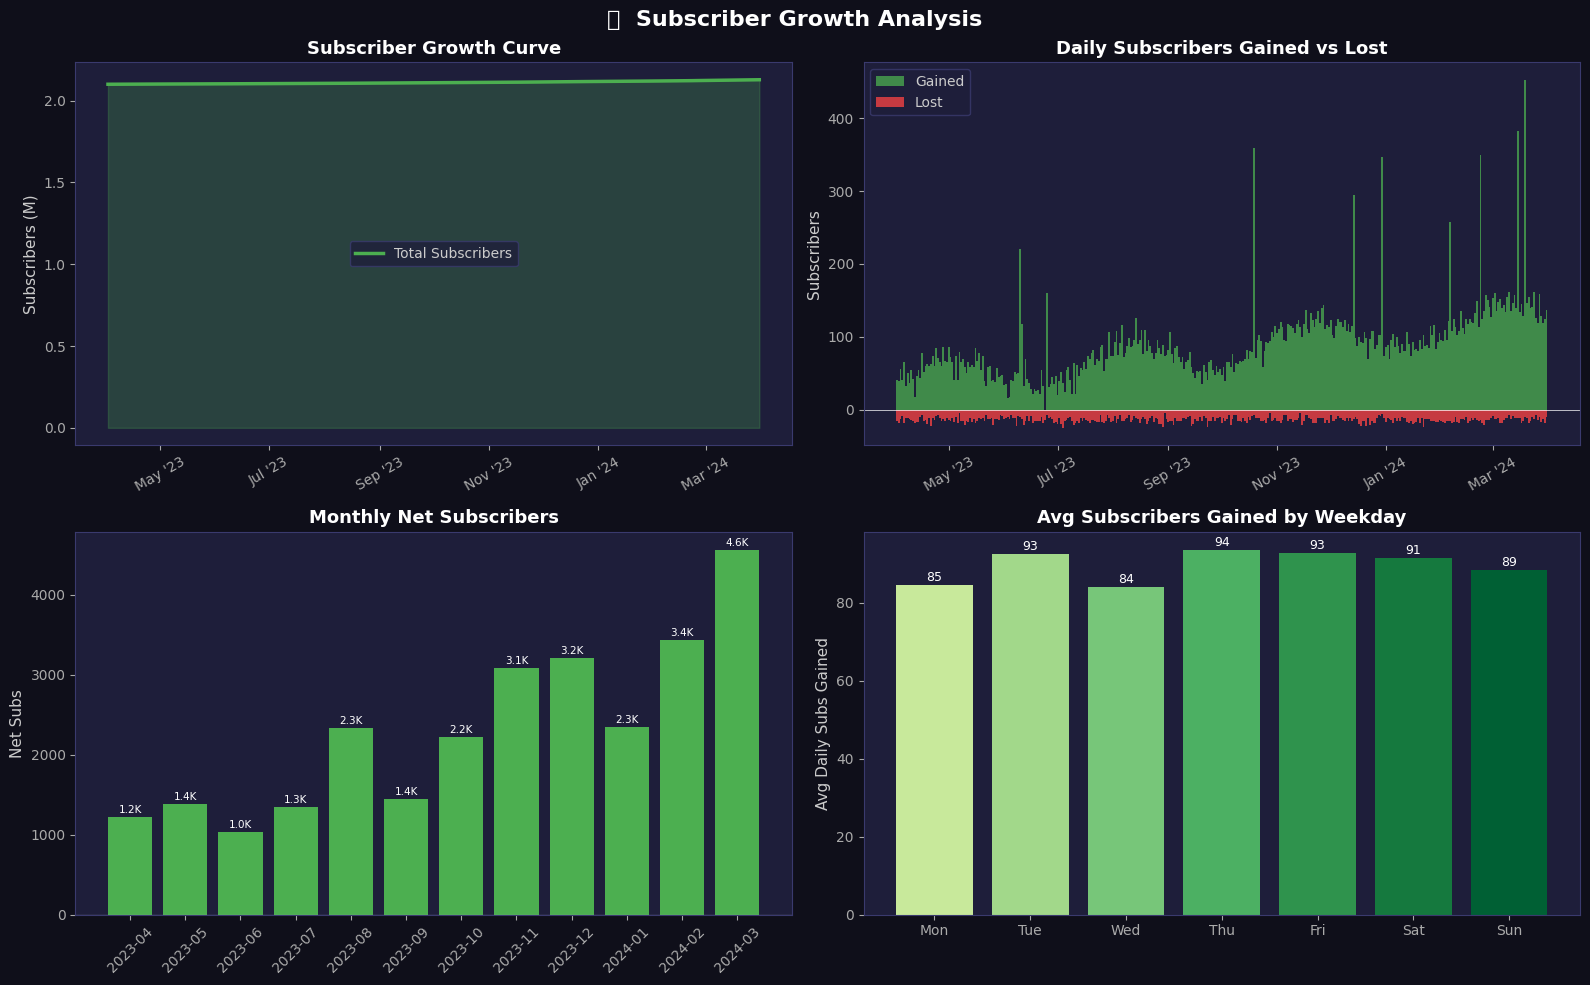

💾  Saved: yt_02_subscriber_growth.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('📈  Subscriber Growth Analysis', fontsize=16,
             color='white', fontweight='bold')

# ── Subscriber total curve ────────────────────────────────────
ax = axes[0, 0]
ax.fill_between(ts['date'], ts['subscribers']/1e6,
                alpha=0.25, color=C_SUBS)
ax.plot(ts['date'], ts['subscribers']/1e6,
        color=C_SUBS, lw=2.5, label='Total Subscribers')
ax.set_title('Subscriber Growth Curve')
ax.set_ylabel('Subscribers (M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.tick_params(axis='x', rotation=30)
ax.legend()

# ── Daily gained vs lost ──────────────────────────────────────
ax2 = axes[0, 1]
ax2.bar(ts['date'], ts['subs_gained'], color=C_SUBS,
        alpha=0.75, width=1.0, label='Gained')
ax2.bar(ts['date'], -ts['subs_lost'], color=ACCENT,
        alpha=0.75, width=1.0, label='Lost')
ax2.axhline(0, color='white', lw=0.5)
ax2.set_title('Daily Subscribers Gained vs Lost')
ax2.set_ylabel('Subscribers')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

# ── Monthly net subs ──────────────────────────────────────────
ax3    = axes[1, 0]
mon_ns = ts.groupby('month')['net_subs'].sum().reset_index()
colors_ns = [C_SUBS if v >= 0 else ACCENT for v in mon_ns['net_subs']]
bars = ax3.bar(mon_ns['month'], mon_ns['net_subs'],
               color=colors_ns, edgecolor='none')
for bar, val in zip(bars, mon_ns['net_subs']):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (50 if val >= 0 else -200),
             fmt(val), ha='center', fontsize=7.5, color='white')
ax3.set_title('Monthly Net Subscribers')
ax3.set_ylabel('Net Subs')
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(0, color='white', lw=0.8)

# ── Subs gained by weekday ────────────────────────────────────
ax4     = axes[1, 1]
wday_o  = ['Monday','Tuesday','Wednesday','Thursday',
            'Friday','Saturday','Sunday']
wday_ns = ts.groupby('weekday')['subs_gained'].mean().reindex(wday_o)
colors_wd = plt.cm.YlGn(np.linspace(0.3, 0.9, 7))
bars4 = ax4.bar(range(7), wday_ns.values, color=colors_wd, edgecolor='none')
for bar, val in zip(bars4, wday_ns.values):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1, f'{val:.0f}',
             ha='center', fontsize=9, color='white')
ax4.set_xticks(range(7))
ax4.set_xticklabels([d[:3] for d in wday_o])
ax4.set_title('Avg Subscribers Gained by Weekday')
ax4.set_ylabel('Avg Daily Subs Gained')

plt.tight_layout()
plt.savefig('yt_02_subscriber_growth.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_02_subscriber_growth.png')

---
## Step 6 — Video Performance Analysis

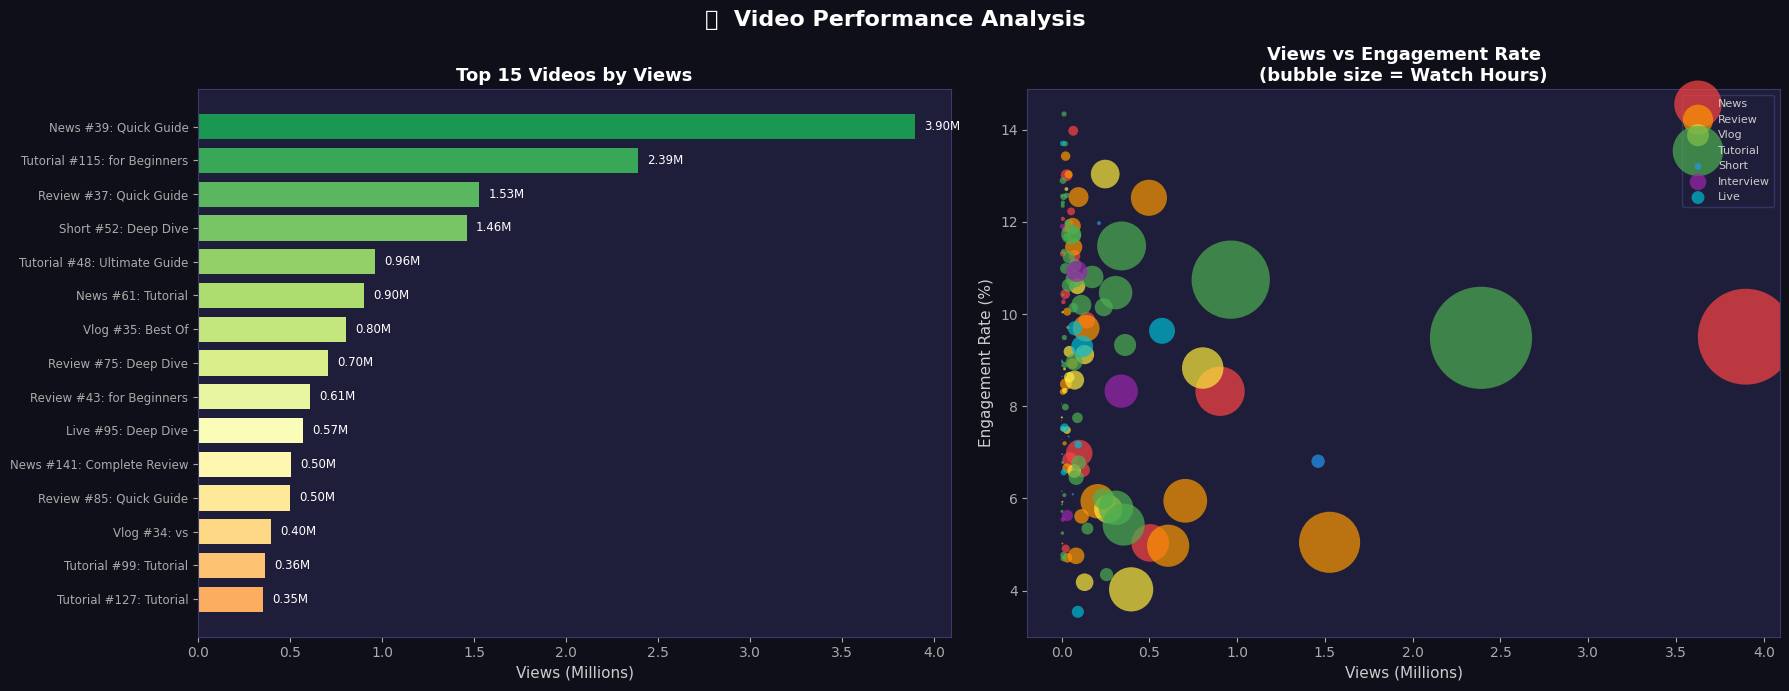

💾  Saved: yt_03_video_performance.png


In [10]:
# ── Top 15 videos by views ────────────────────────────────────
top15 = videos.nlargest(15, 'views')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('🏆  Video Performance Analysis', fontsize=16,
             color='white', fontweight='bold')

# Horizontal bar — top 15
ax1 = axes[0]
colors_top = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
bars = ax1.barh(range(15), top15['views'][::-1].values/1e6,
                color=colors_top, edgecolor='none', height=0.75)
for i, (bar, row) in enumerate(zip(bars, top15[::-1].itertuples())):
    ax1.text(bar.get_width()+0.05,
             bar.get_y()+bar.get_height()/2,
             f'{row.views/1e6:.2f}M', va='center',
             fontsize=8.5, color='white')
ax1.set_yticks(range(15))
ax1.set_yticklabels(
    [t[:38]+'…' if len(t)>38 else t
     for t in top15['title'][::-1].values],
    fontsize=8.5
)
ax1.set_xlabel('Views (Millions)')
ax1.set_title('Top 15 Videos by Views')

# Scatter — views vs engagement
ax2 = axes[1]
cats = videos['category'].unique()
cat_colors = dict(zip(cats, PALETTE[:len(cats)]))
for cat in cats:
    sub = videos[videos['category'] == cat]
    sc = ax2.scatter(sub['views']/1e6, sub['engagement_rate'],
                     s=sub['watch_hours']/200,
                     color=cat_colors[cat], alpha=0.7,
                     edgecolors='none', label=cat)
ax2.set_xlabel('Views (Millions)')
ax2.set_ylabel('Engagement Rate (%)')
ax2.set_title('Views vs Engagement Rate\n(bubble size = Watch Hours)')
ax2.legend(fontsize=8, markerscale=0.7, loc='upper right')

plt.tight_layout()
plt.savefig('yt_03_video_performance.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_03_video_performance.png')

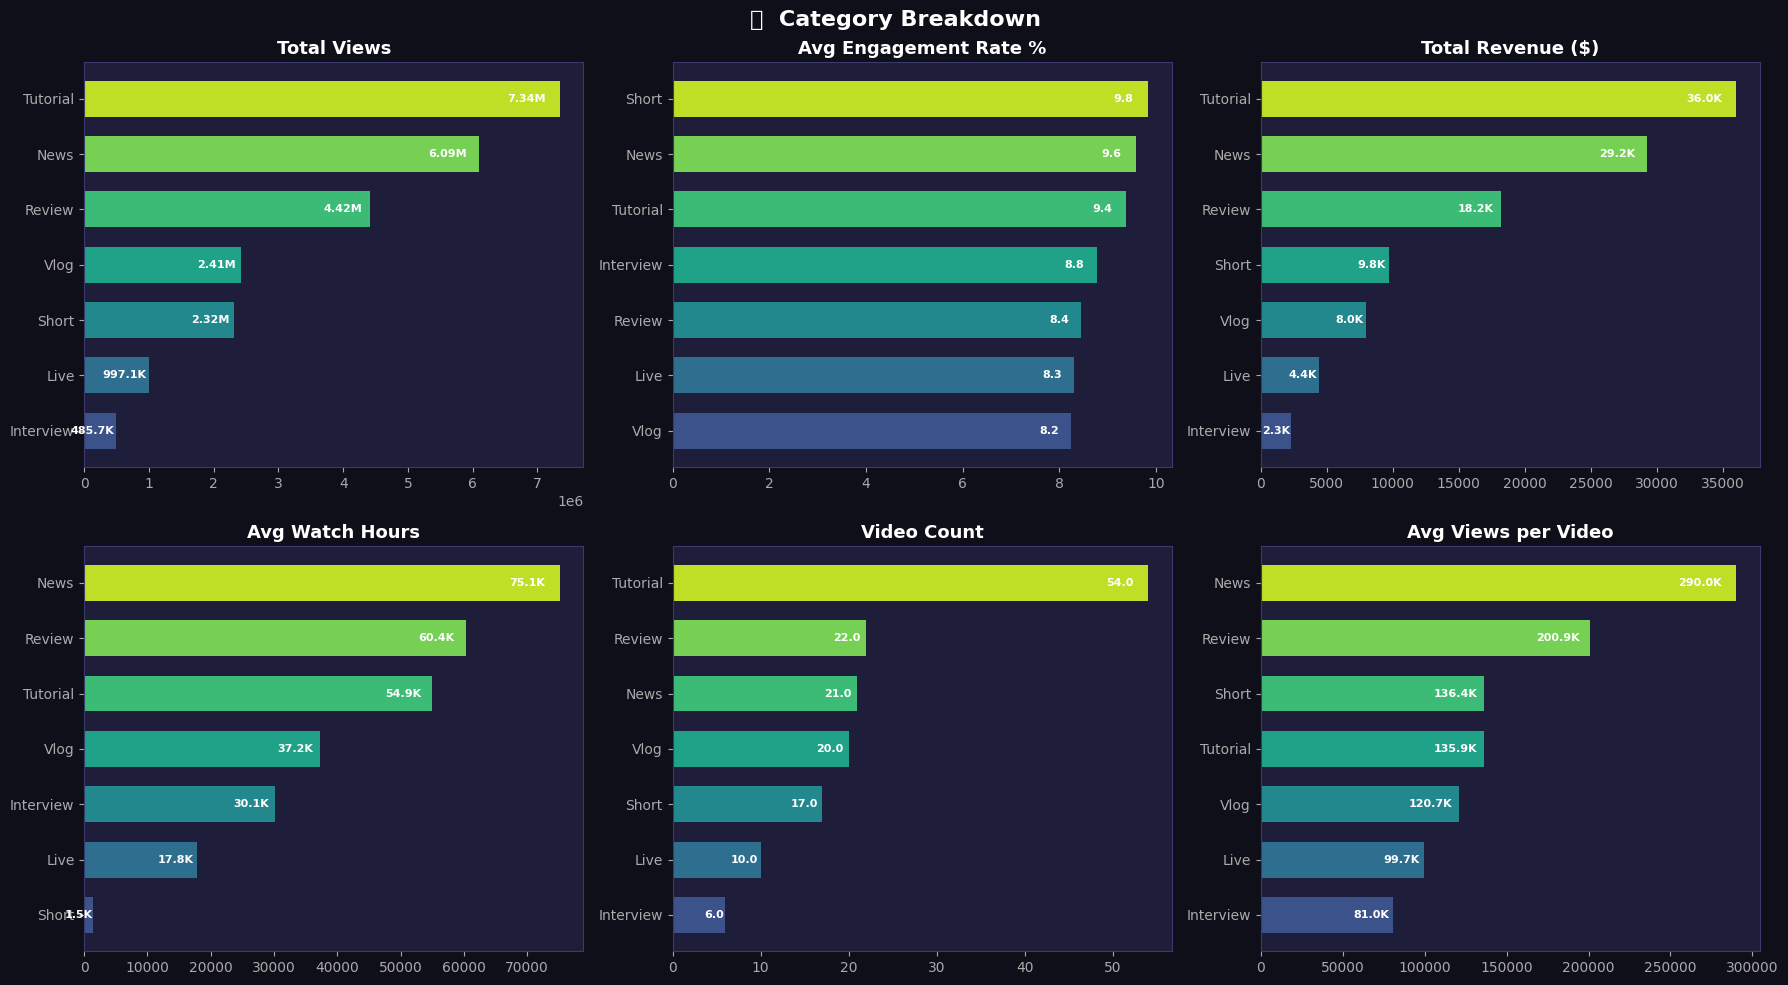

💾  Saved: yt_04_category_breakdown.png


In [11]:
# ── Category Performance ──────────────────────────────────────
cat_stats = videos.groupby('category').agg(
    count        = ('video_id','count'),
    total_views  = ('views','sum'),
    avg_views    = ('views','mean'),
    avg_engage   = ('engagement_rate','mean'),
    total_revenue= ('revenue_usd','sum'),
    avg_watch_h  = ('watch_hours','mean'),
).round(2).sort_values('total_views', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('📂  Category Breakdown', fontsize=16,
             color='white', fontweight='bold')

cat_colors = [PALETTE[i % len(PALETTE)] for i in range(len(cat_stats))]

metrics_plots = [
    ('total_views',   'Total Views',          C_VIEWS),
    ('avg_engage',    'Avg Engagement Rate %', C_ENGAGE),
    ('total_revenue', 'Total Revenue ($)',     C_REV),
    ('avg_watch_h',   'Avg Watch Hours',       C_WATCH),
    ('count',         'Video Count',           '#FFEB3B'),
    ('avg_views',     'Avg Views per Video',   '#E91E63'),
]

for ax, (col, label, color) in zip(axes.flat, metrics_plots):
    sorted_cs = cat_stats.sort_values(col)
    c_grad = plt.cm.viridis(np.linspace(0.25, 0.9, len(sorted_cs)))
    bars = ax.barh(sorted_cs.index, sorted_cs[col],
                   color=c_grad, edgecolor='none', height=0.65)
    for bar, val in zip(bars, sorted_cs[col]):
        ax.text(bar.get_width()*0.97,
                bar.get_y()+bar.get_height()/2,
                fmt(val) if val >= 1000 else f'{val:.1f}',
                va='center', ha='right',
                color='white', fontsize=8, fontweight='bold')
    ax.set_title(label)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('yt_04_category_breakdown.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_04_category_breakdown.png')

---
## Step 7 — Views & Watch Time Trends

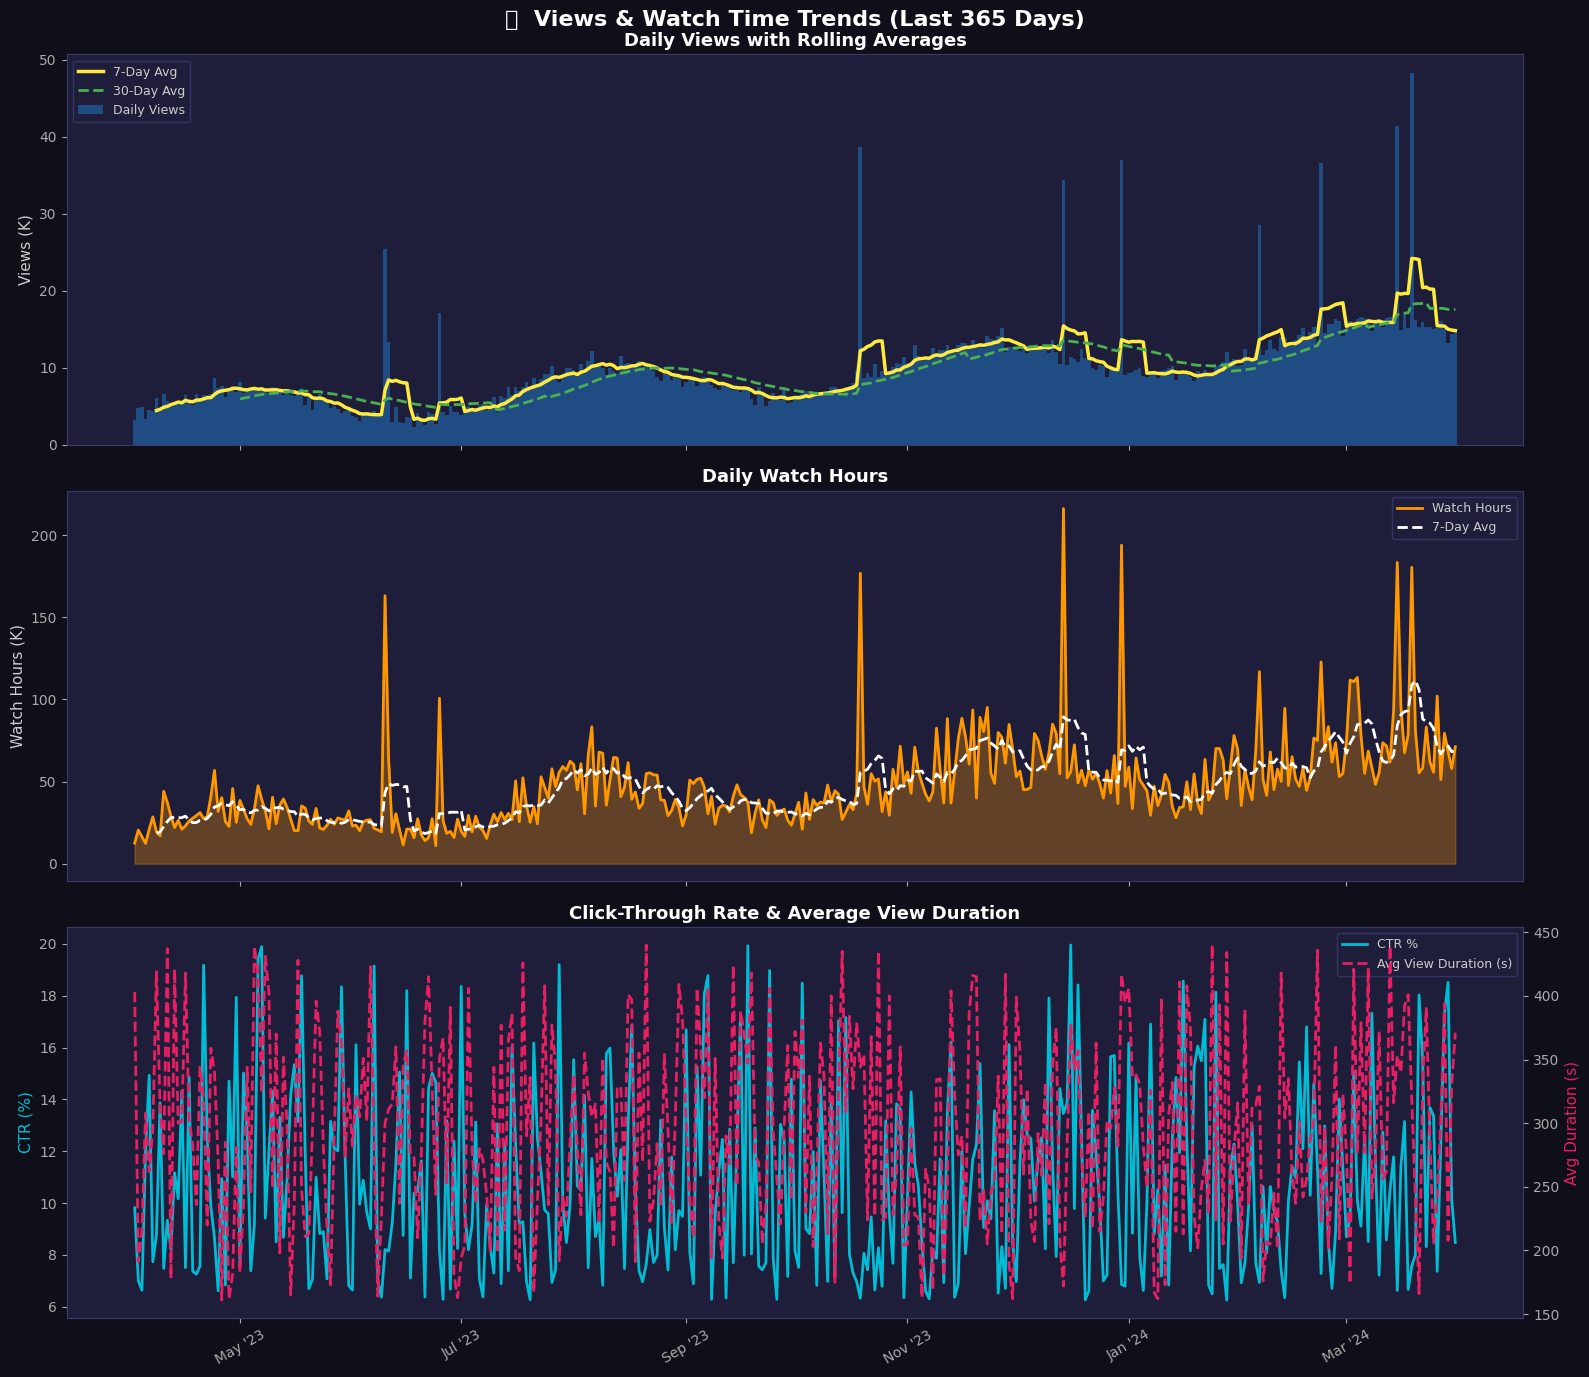

💾  Saved: yt_05_views_watchtime.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('📊  Views & Watch Time Trends (Last 365 Days)',
             fontsize=16, color='white', fontweight='bold')

# Daily views
axes[0].bar(ts['date'], ts['views']/1e3, color=C_VIEWS,
            alpha=0.4, width=1.0, label='Daily Views')
axes[0].plot(ts['date'], ts['views_7d']/1e3,
             color='#FFEB3B', lw=2.5, label='7-Day Avg')
axes[0].plot(ts['date'], ts['views_30d']/1e3,
             color=C_SUBS, lw=2, linestyle='--', label='30-Day Avg')
axes[0].set_ylabel('Views (K)')
axes[0].set_title('Daily Views with Rolling Averages')
axes[0].legend(fontsize=9)

# Watch hours
axes[1].fill_between(ts['date'], ts['watch_hours']/1e3,
                     alpha=0.3, color=C_WATCH)
axes[1].plot(ts['date'], ts['watch_hours']/1e3,
             color=C_WATCH, lw=2, label='Watch Hours')
axes[1].plot(ts['date'], ts['watch_7d']/1e3,
             color='white', lw=2, linestyle='--', label='7-Day Avg')
axes[1].set_ylabel('Watch Hours (K)')
axes[1].set_title('Daily Watch Hours')
axes[1].legend(fontsize=9)

# CTR & Avg view duration
ax_r = axes[2].twinx()
axes[2].plot(ts['date'], ts['ctr_pct'], color=C_ENGAGE,
             lw=2, label='CTR %')
ax_r.plot(ts['date'], ts['avg_view_dur'], color='#E91E63',
          lw=2, label='Avg View Duration (s)', linestyle='--')
axes[2].set_ylabel('CTR (%)', color=C_ENGAGE)
ax_r.set_ylabel('Avg Duration (s)', color='#E91E63')
axes[2].set_title('Click-Through Rate & Average View Duration')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[2].tick_params(axis='x', rotation=30)
lines1, labs1 = axes[2].get_legend_handles_labels()
lines2, labs2 = ax_r.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labs1+labs2, fontsize=9)

plt.tight_layout()
plt.savefig('yt_05_views_watchtime.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_05_views_watchtime.png')

---
## Step 8 — Engagement Deep Dive

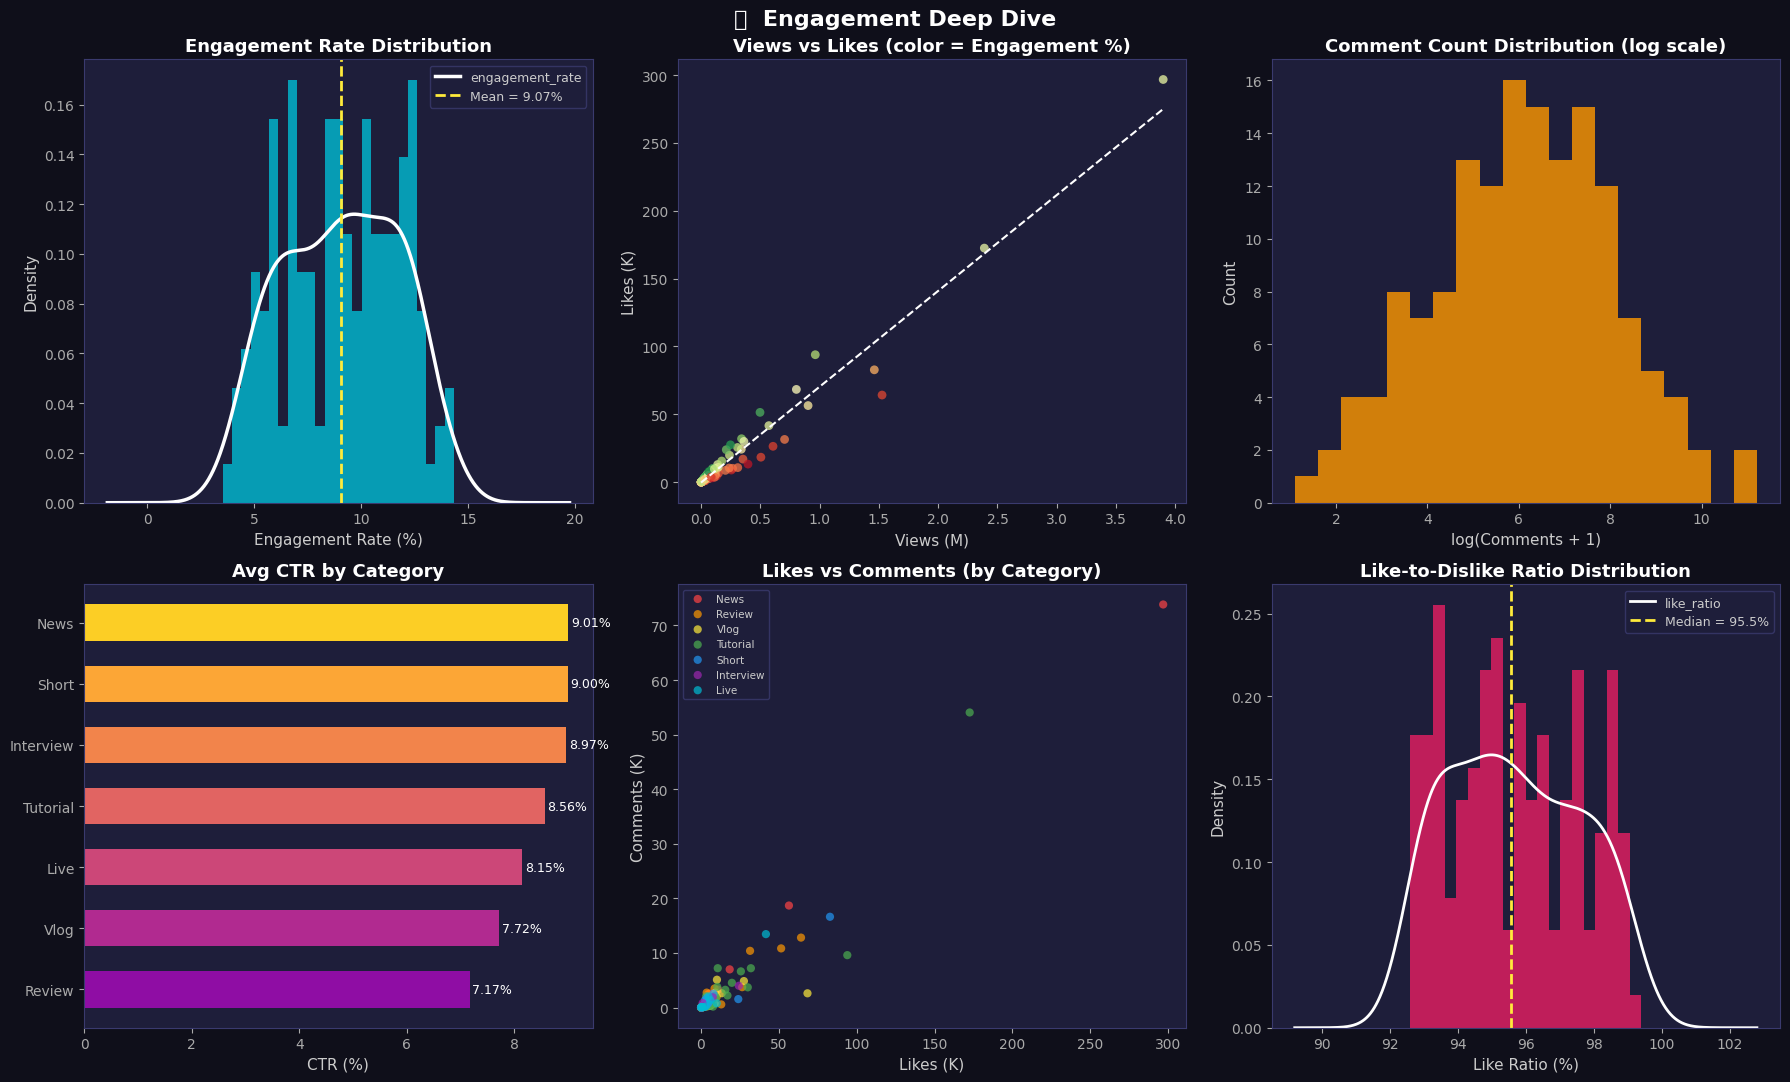

💾  Saved: yt_06_engagement.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('💬  Engagement Deep Dive', fontsize=16,
             color='white', fontweight='bold')

# Engagement distribution
ax = axes[0, 0]
ax.hist(videos['engagement_rate'], bins=25, color=C_ENGAGE,
        edgecolor='none', alpha=0.8, density=True)
videos['engagement_rate'].plot.kde(ax=ax, color='white', lw=2.5)
ax.axvline(videos['engagement_rate'].mean(), color='#FFEB3B',
           lw=2, linestyle='--',
           label=f'Mean = {videos["engagement_rate"].mean():.2f}%')
ax.set_title('Engagement Rate Distribution')
ax.set_xlabel('Engagement Rate (%)')
ax.legend(fontsize=9)

# Likes vs Views
ax2 = axes[0, 1]
ax2.scatter(videos['views']/1e6, videos['likes']/1e3,
            c=videos['engagement_rate'],
            cmap='RdYlGn', s=40, alpha=0.75, edgecolors='none')
m, b = np.polyfit(videos['views']/1e6, videos['likes']/1e3, 1)
xl = np.linspace(0, videos['views'].max()/1e6, 100)
ax2.plot(xl, m*xl+b, color='white', lw=1.5, linestyle='--')
ax2.set_xlabel('Views (M)')
ax2.set_ylabel('Likes (K)')
ax2.set_title('Views vs Likes (color = Engagement %)')

# Comments distribution
ax3 = axes[0, 2]
ax3.hist(np.log1p(videos['comments']), bins=20, color='#FF9800',
         edgecolor='none', alpha=0.8)
ax3.set_xlabel('log(Comments + 1)')
ax3.set_ylabel('Count')
ax3.set_title('Comment Count Distribution (log scale)')

# CTR by category
ax4 = axes[1, 0]
ctr_cat = videos.groupby('category')['ctr_pct'].mean().sort_values(ascending=True)
colors_ctr = plt.cm.plasma(np.linspace(0.3, 0.9, len(ctr_cat)))
bars = ax4.barh(ctr_cat.index, ctr_cat.values,
                color=colors_ctr, edgecolor='none', height=0.6)
for bar, val in zip(bars, ctr_cat.values):
    ax4.text(bar.get_width()+0.05,
             bar.get_y()+bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9, color='white')
ax4.set_title('Avg CTR by Category')
ax4.set_xlabel('CTR (%)')

# Likes vs comments
ax5 = axes[1, 1]
for cat, color in zip(cats, PALETTE):
    sub = videos[videos['category'] == cat]
    ax5.scatter(sub['likes']/1e3, sub['comments']/1e3,
                label=cat, color=color, s=35, alpha=0.7,
                edgecolors='none')
ax5.set_xlabel('Likes (K)')
ax5.set_ylabel('Comments (K)')
ax5.set_title('Likes vs Comments (by Category)')
ax5.legend(fontsize=7.5, markerscale=1.0)

# Like ratio distribution
ax6 = axes[1, 2]
ax6.hist(videos['like_ratio'], bins=20, color='#E91E63',
         edgecolor='none', alpha=0.8, density=True)
videos['like_ratio'].plot.kde(ax=ax6, color='white', lw=2)
ax6.set_xlabel('Like Ratio (%)')
ax6.set_ylabel('Density')
ax6.set_title('Like-to-Dislike Ratio Distribution')
ax6.axvline(videos['like_ratio'].median(), color='#FFEB3B',
            lw=2, linestyle='--',
            label=f'Median = {videos["like_ratio"].median():.1f}%')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('yt_06_engagement.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_06_engagement.png')

---
## Step 9 — Revenue Analysis

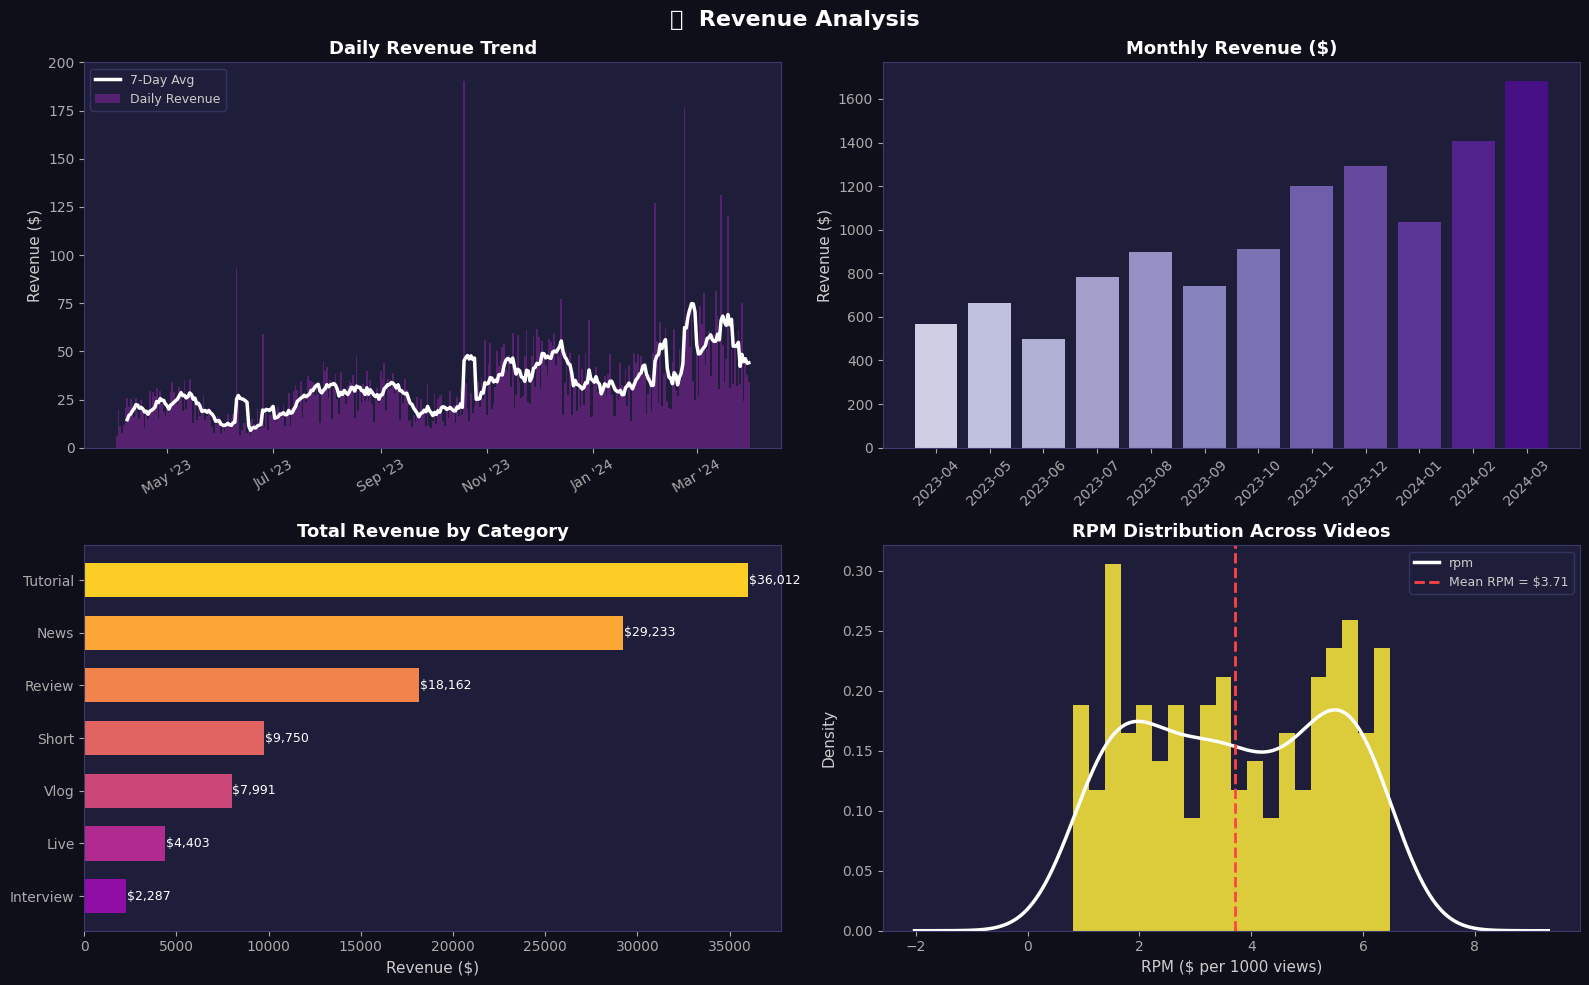


📊  Total Annual Revenue  : $11,686
   Daily Average Revenue : $32
   Peak Day Revenue      : $190
   Avg RPM               : $3.71
💾  Saved: yt_07_revenue.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('💰  Revenue Analysis', fontsize=16,
             color='white', fontweight='bold')

# Daily revenue with 7-day avg
axes[0,0].bar(ts['date'], ts['revenue_usd'], color=C_REV,
              alpha=0.45, width=1.0, label='Daily Revenue')
axes[0,0].plot(ts['date'], ts['rev_7d'], color='white',
               lw=2.5, label='7-Day Avg')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].set_title('Daily Revenue Trend')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(fontsize=9)

# Monthly revenue
mon_rev = ts.groupby('month')['revenue_usd'].sum().reset_index()
clrs_m  = plt.cm.Purples(np.linspace(0.3, 0.95, len(mon_rev)))
axes[0,1].bar(mon_rev['month'], mon_rev['revenue_usd'],
              color=clrs_m, edgecolor='none')
axes[0,1].set_title('Monthly Revenue ($)')
axes[0,1].set_ylabel('Revenue ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Revenue by category
rev_cat = videos.groupby('category')['revenue_usd'].sum().sort_values()
colors_rev = plt.cm.plasma(np.linspace(0.3, 0.9, len(rev_cat)))
axes[1,0].barh(rev_cat.index, rev_cat.values, color=colors_rev,
               edgecolor='none', height=0.65)
for i, val in enumerate(rev_cat.values):
    axes[1,0].text(val + 50, i, f'${val:,.0f}',
                   va='center', fontsize=9, color='white')
axes[1,0].set_title('Total Revenue by Category')
axes[1,0].set_xlabel('Revenue ($)')

# RPM distribution
axes[1,1].hist(videos['rpm'], bins=20, color='#FFEB3B',
               edgecolor='none', alpha=0.85, density=True)
videos['rpm'].plot.kde(ax=axes[1,1], color='white', lw=2.5)
axes[1,1].axvline(videos['rpm'].mean(), color=ACCENT,
                  lw=2, linestyle='--',
                  label=f'Mean RPM = ${videos["rpm"].mean():.2f}')
axes[1,1].set_xlabel('RPM ($ per 1000 views)')
axes[1,1].set_title('RPM Distribution Across Videos')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('yt_07_revenue.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print(f'\n📊  Total Annual Revenue  : ${ts["revenue_usd"].sum():,.0f}')
print(f'   Daily Average Revenue : ${ts["revenue_usd"].mean():,.0f}')
print(f'   Peak Day Revenue      : ${ts["revenue_usd"].max():,.0f}')
print(f'   Avg RPM               : ${videos["rpm"].mean():.2f}')
print('💾  Saved: yt_07_revenue.png')

---
## Step 10 — Audience Demographics

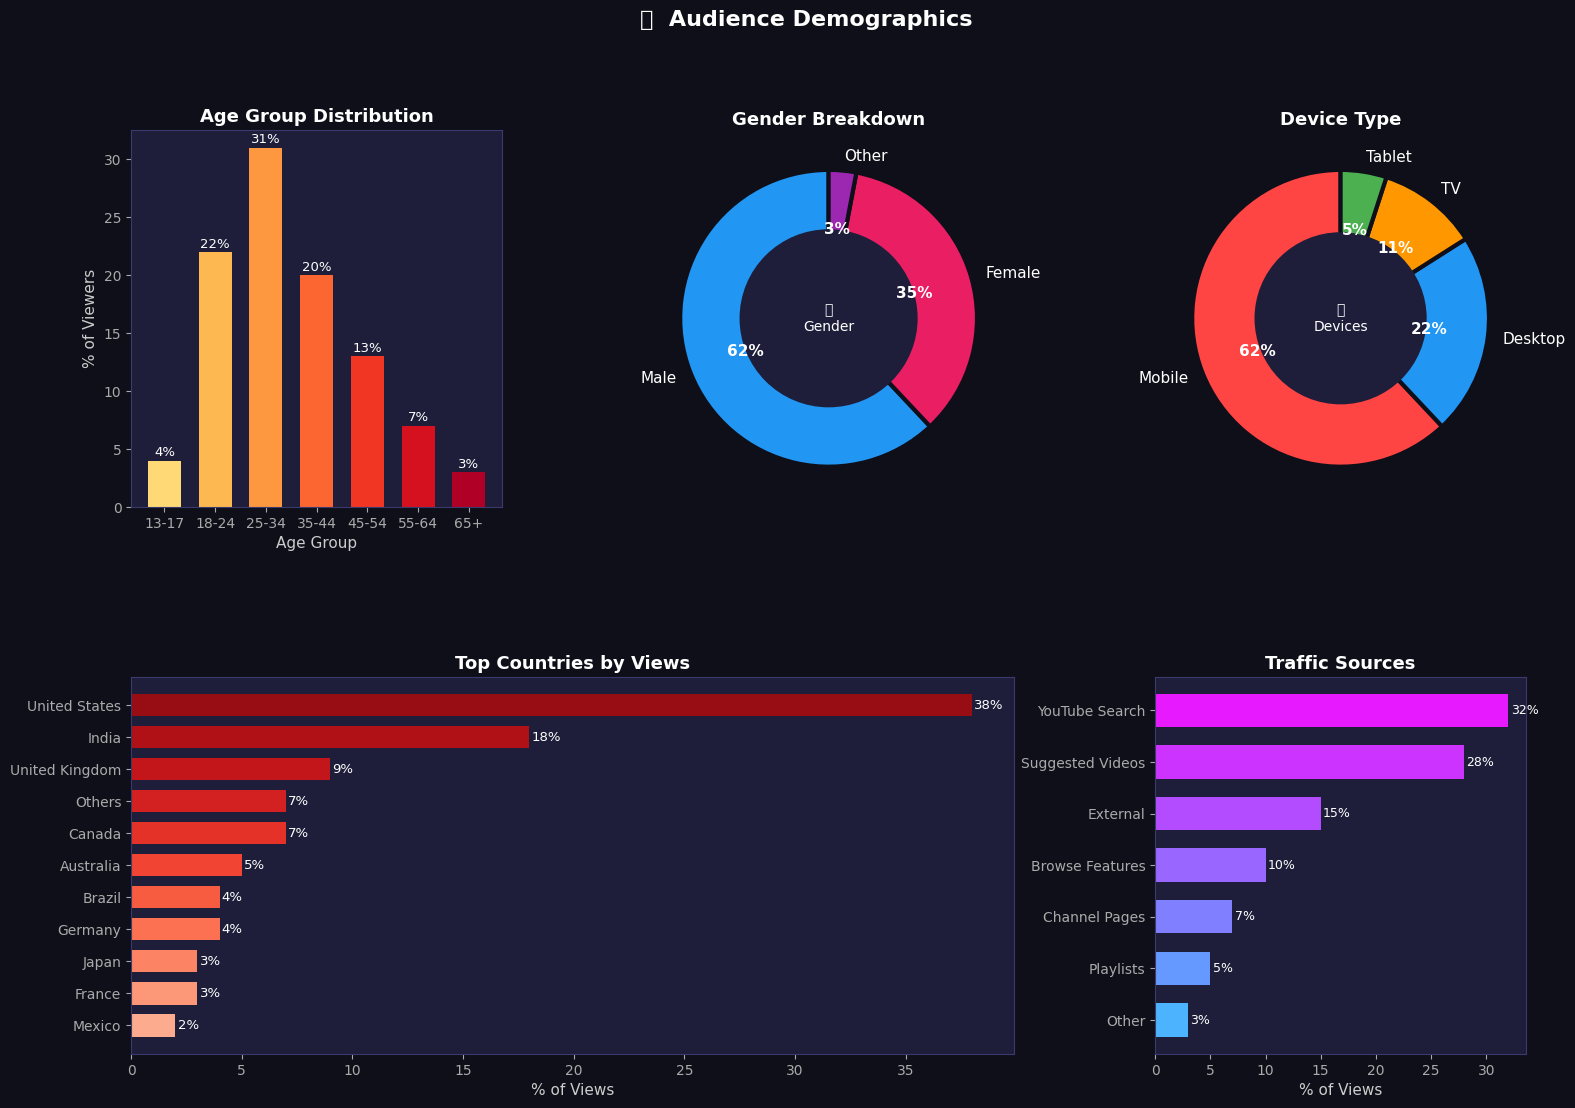

💾  Saved: yt_08_demographics.png


In [15]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(DARK_BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('👥  Audience Demographics', fontsize=16,
             color='white', fontweight='bold')

age_df  = demo['age']
gen_d   = demo['gender']
geo_df  = demo['geo']
traf_df = demo['traffic']
dev_df  = demo['devices']

# Age group
ax1 = fig.add_subplot(gs[0, 0])
clrs_age = plt.cm.YlOrRd(np.linspace(0.25, 0.9, len(age_df)))
bars = ax1.bar(age_df['group'], age_df['pct'],
               color=clrs_age, edgecolor='none', width=0.65)
for bar, val in zip(bars, age_df['pct']):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.4,
             f'{val}%', ha='center', fontsize=9.5, color='white')
ax1.set_title('Age Group Distribution')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('% of Viewers')

# Gender donut
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD_BG)
wedges, texts, auts = ax2.pie(
    list(gen_d.values()),
    labels=list(gen_d.keys()),
    colors=['#2196F3','#E91E63','#9C27B0'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':DARK_BG,'linewidth':3},
    textprops={'color':'white','fontsize':11}
)
for at in auts: at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.60, fc=CARD_BG)
ax2.add_artist(centre)
ax2.text(0, 0, '👥\nGender', ha='center', va='center',
         fontsize=10, color='white')
ax2.set_title('Gender Breakdown')

# Device donut
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(CARD_BG)
wedges2, _, auts2 = ax3.pie(
    dev_df['pct'], labels=dev_df['device'],
    colors=[ACCENT,'#2196F3','#FF9800','#4CAF50'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':DARK_BG,'linewidth':3},
    textprops={'color':'white','fontsize':11}
)
for at in auts2: at.set_fontweight('bold')
centre2 = plt.Circle((0,0), 0.58, fc=CARD_BG)
ax3.add_artist(centre2)
ax3.text(0, 0, '📱\nDevices', ha='center', va='center',
         fontsize=10, color='white')
ax3.set_title('Device Type')

# Top countries
ax4 = fig.add_subplot(gs[1, :2])
geo_s = geo_df.sort_values('pct', ascending=True)
clrs_geo = plt.cm.Reds(np.linspace(0.3, 0.9, len(geo_s)))
bars_g = ax4.barh(geo_s['country'], geo_s['pct'],
                  color=clrs_geo, edgecolor='none', height=0.7)
for bar, val in zip(bars_g, geo_s['pct']):
    ax4.text(bar.get_width()+0.1,
             bar.get_y()+bar.get_height()/2,
             f'{val}%', va='center', fontsize=9.5, color='white')
ax4.set_title('Top Countries by Views')
ax4.set_xlabel('% of Views')

# Traffic sources — horizontal bar
ax5 = fig.add_subplot(gs[1, 2])
traf_s = traf_df.sort_values('pct', ascending=True)
clrs_tr = plt.cm.cool(np.linspace(0.3, 0.9, len(traf_s)))
bars_t = ax5.barh(traf_s['source'], traf_s['pct'],
                  color=clrs_tr, edgecolor='none', height=0.65)
for bar, val in zip(bars_t, traf_s['pct']):
    ax5.text(bar.get_width()+0.2,
             bar.get_y()+bar.get_height()/2,
             f'{val}%', va='center', fontsize=9, color='white')
ax5.set_title('Traffic Sources')
ax5.set_xlabel('% of Views')

plt.savefig('yt_08_demographics.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_08_demographics.png')

---
## Step 11 — Optimal Posting Time Analysis

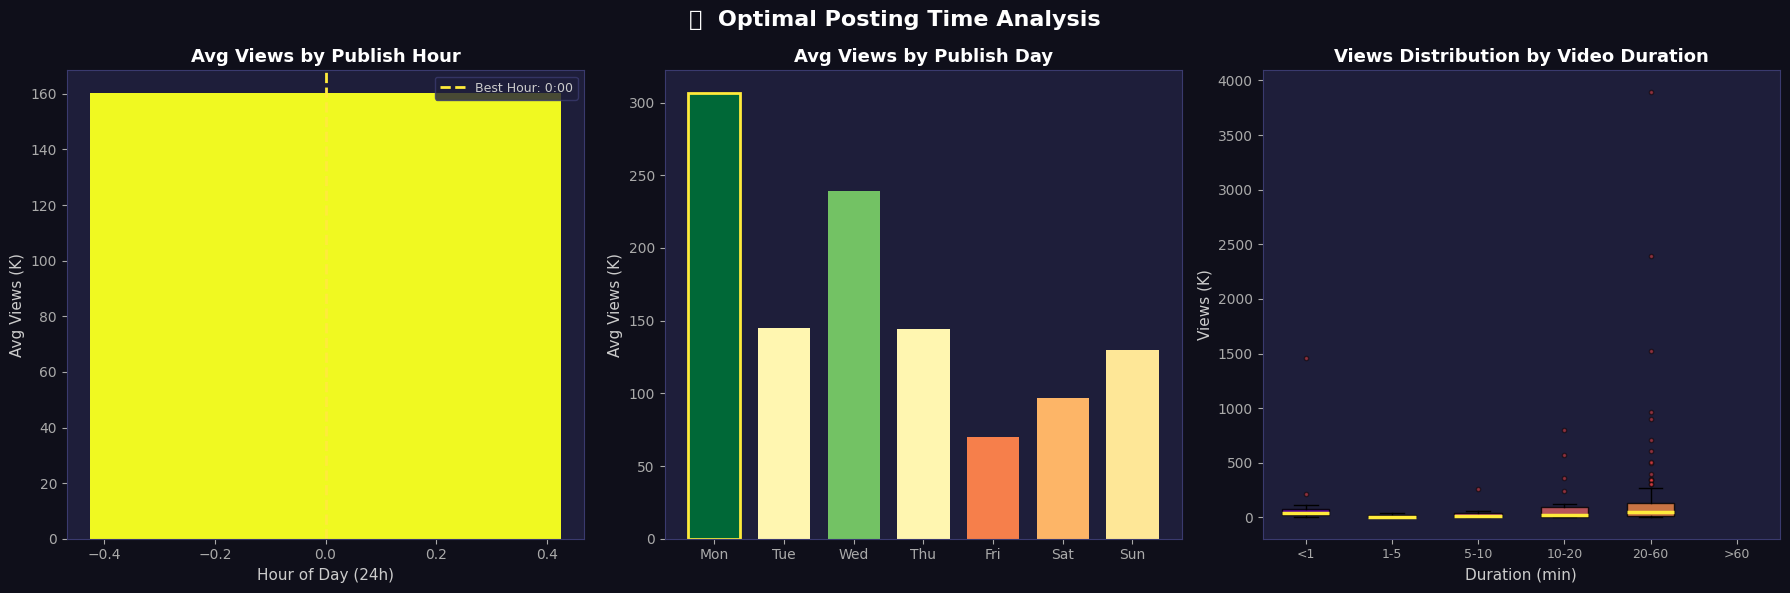

💾  Saved: yt_09_posting_time.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('🕐  Optimal Posting Time Analysis', fontsize=16,
             color='white', fontweight='bold')

# By hour
hr_perf = videos.groupby('pub_hour')['views'].mean()
clrs_hr = plt.cm.plasma(hr_perf.values / hr_perf.max())
axes[0].bar(hr_perf.index, hr_perf.values/1e3, color=clrs_hr,
            edgecolor='none', width=0.85)
best_hr = hr_perf.idxmax()
axes[0].axvline(best_hr, color='#FFEB3B', lw=2, linestyle='--',
                label=f'Best Hour: {best_hr}:00')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Avg Views (K)')
axes[0].set_title('Avg Views by Publish Hour')
axes[0].legend(fontsize=9)

# By weekday
wday_o  = ['Monday','Tuesday','Wednesday','Thursday',
            'Friday','Saturday','Sunday']
wd_perf = videos.groupby('pub_weekday')['views'].mean().reindex(wday_o)
clrs_wd = plt.cm.RdYlGn(wd_perf.values / wd_perf.max())
axes[1].bar(range(7), wd_perf.values/1e3, color=clrs_wd,
            edgecolor='none', width=0.75)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in wday_o])
axes[1].set_ylabel('Avg Views (K)')
axes[1].set_title('Avg Views by Publish Day')
best_day_idx = wd_perf.values.argmax()
axes[1].get_children()[best_day_idx].set_edgecolor('#FFEB3B')
axes[1].get_children()[best_day_idx].set_linewidth(2)

# Duration vs views box
dur_data = [videos[videos['dur_band']==d]['views'].dropna().values/1e3
            for d in ['<1 min','1-5 min','5-10 min',
                      '10-20 min','20-60 min','>60 min']]
bp = axes[2].boxplot(dur_data, patch_artist=True, widths=0.55,
                     medianprops=dict(color='#FFEB3B', lw=2.5),
                     flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor=ACCENT, alpha=0.5))
box_c = plt.cm.plasma(np.linspace(0.2, 0.85, 6))
for patch, c in zip(bp['boxes'], box_c):
    patch.set_facecolor(c); patch.set_alpha(0.8)
axes[2].set_xticklabels(['<1','1-5','5-10','10-20','20-60','>60'],
                         fontsize=9)
axes[2].set_xlabel('Duration (min)')
axes[2].set_ylabel('Views (K)')
axes[2].set_title('Views Distribution by Video Duration')

plt.tight_layout()
plt.savefig('yt_09_posting_time.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_09_posting_time.png')

---
## Step 12 — Correlation Analysis

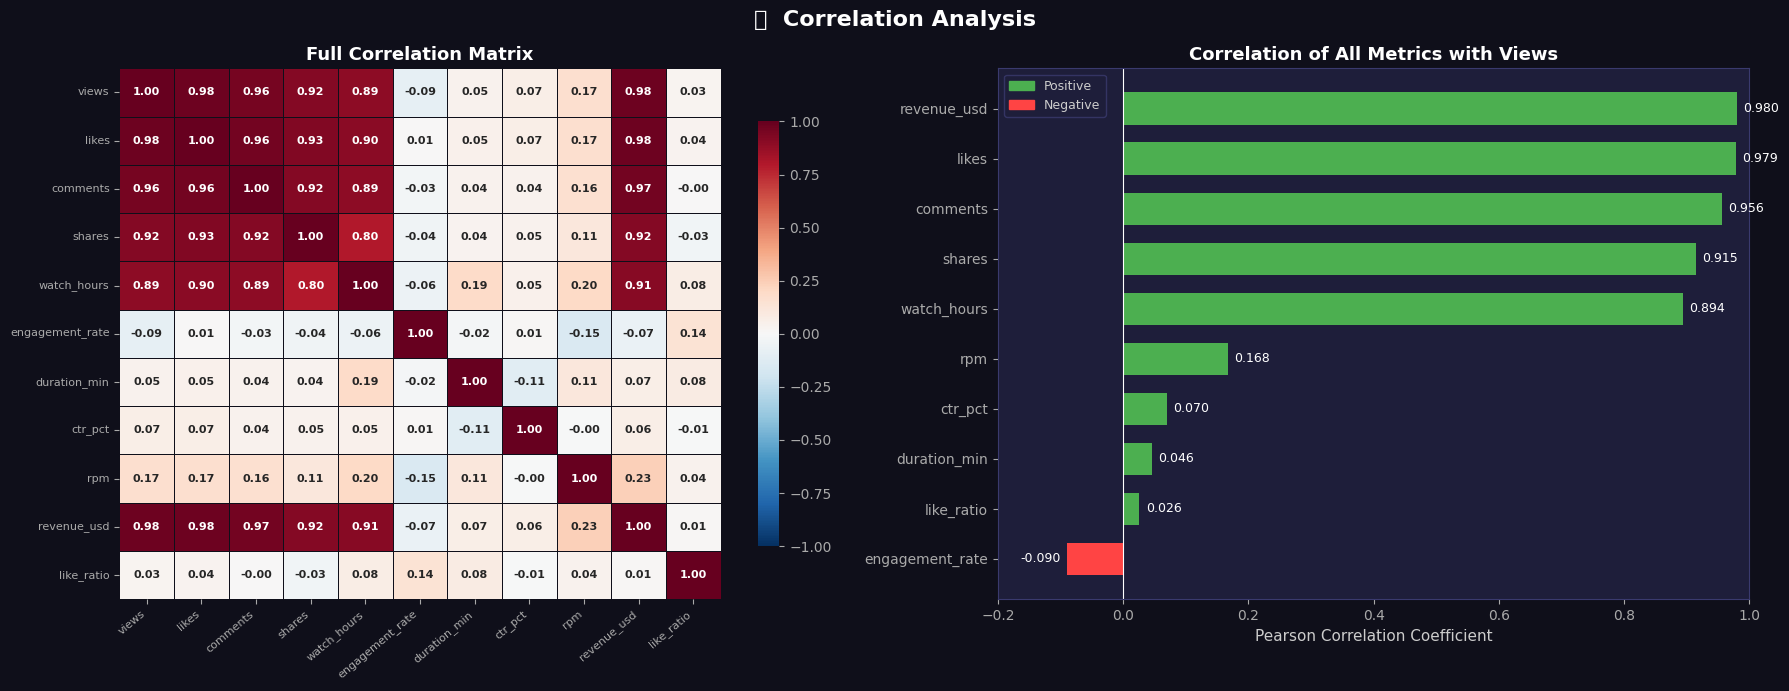

💾  Saved: yt_10_correlation.png


In [17]:
corr_cols = ['views','likes','comments','shares','watch_hours',
             'engagement_rate','duration_min','ctr_pct',
             'rpm','revenue_usd','like_ratio']
corr_m    = videos[corr_cols].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('🔗  Correlation Analysis', fontsize=16,
             color='white', fontweight='bold')

# Full heatmap
mask = np.zeros_like(corr_m, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_m, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, linecolor=DARK_BG,
            annot_kws={'size':8, 'weight':'bold'},
            cbar_kws={'shrink':0.8})
axes[0].set_title('Full Correlation Matrix')
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=40, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(),
                         rotation=0, fontsize=8)

# Correlations with views
corr_views = corr_m['views'].drop('views').sort_values()
colors_cv  = [C_SUBS if v >= 0 else ACCENT for v in corr_views.values]
axes[1].barh(corr_views.index, corr_views.values,
             color=colors_cv, edgecolor='none', height=0.65)
for i, val in enumerate(corr_views.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 i, f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=9, color='white')
axes[1].axvline(0, color='white', lw=0.8)
axes[1].set_xlim([-0.2, 1.0])
axes[1].set_title('Correlation of All Metrics with Views')
axes[1].set_xlabel('Pearson Correlation Coefficient')
legend_els = [mpatches.Patch(color=C_SUBS, label='Positive'),
              mpatches.Patch(color=ACCENT,  label='Negative')]
axes[1].legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig('yt_10_correlation.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_10_correlation.png')

In [19]:
from scipy.stats import pearsonr, spearmanr

In [20]:
# ── Pearson & Spearman Tests ───────────────────────────────────
print('── Statistical Correlation Tests ─────────────────────')
test_cols = ['likes','comments','watch_hours','engagement_rate',
             'duration_min','ctr_pct','revenue_usd']
rows = []
for col in test_cols:
    pr, pp = pearsonr( videos['views'], videos[col])
    sr, sp = spearmanr(videos['views'], videos[col])
    rows.append({'Feature':col,
                 'Pearson r':round(pr,4), 'Pearson p':round(pp,4),
                 'Spearman r':round(sr,4),'Spearman p':round(sp,4)})
corr_test_df = pd.DataFrame(rows).set_index('Feature')
corr_test_df['Sig (p<0.05)'] = corr_test_df['Pearson p'].apply(
    lambda p: '✅ Yes' if p < 0.05 else '❌ No'
)
corr_test_df.style \
    .background_gradient(subset=['Pearson r','Spearman r'], cmap='RdBu_r') \
    .format({'Pearson r':'{:.4f}','Pearson p':'{:.4f}',
             'Spearman r':'{:.4f}','Spearman p':'{:.4f}'})

── Statistical Correlation Tests ─────────────────────


,Pearson r,Pearson p,Spearman r,Spearman p,Sig (p<0.05)
Feature,,,,,
likes,0.9787,0.0000,0.9688,0.0000,✅ Yes
comments,0.9565,0.0000,0.9432,0.0000,✅ Yes
watch_hours,0.8943,0.0000,0.8395,0.0000,✅ Yes
engagement_rate,-0.0902,0.2722,-0.1271,0.1213,❌ No
duration_min,0.0464,0.5730,0.1365,0.0959,❌ No
ctr_pct,0.0701,0.3937,0.1814,0.0263,❌ No
revenue_usd,0.9802,0.0000,0.9525,0.0000,✅ Yes


---
## Step 13 — Summary Dashboard

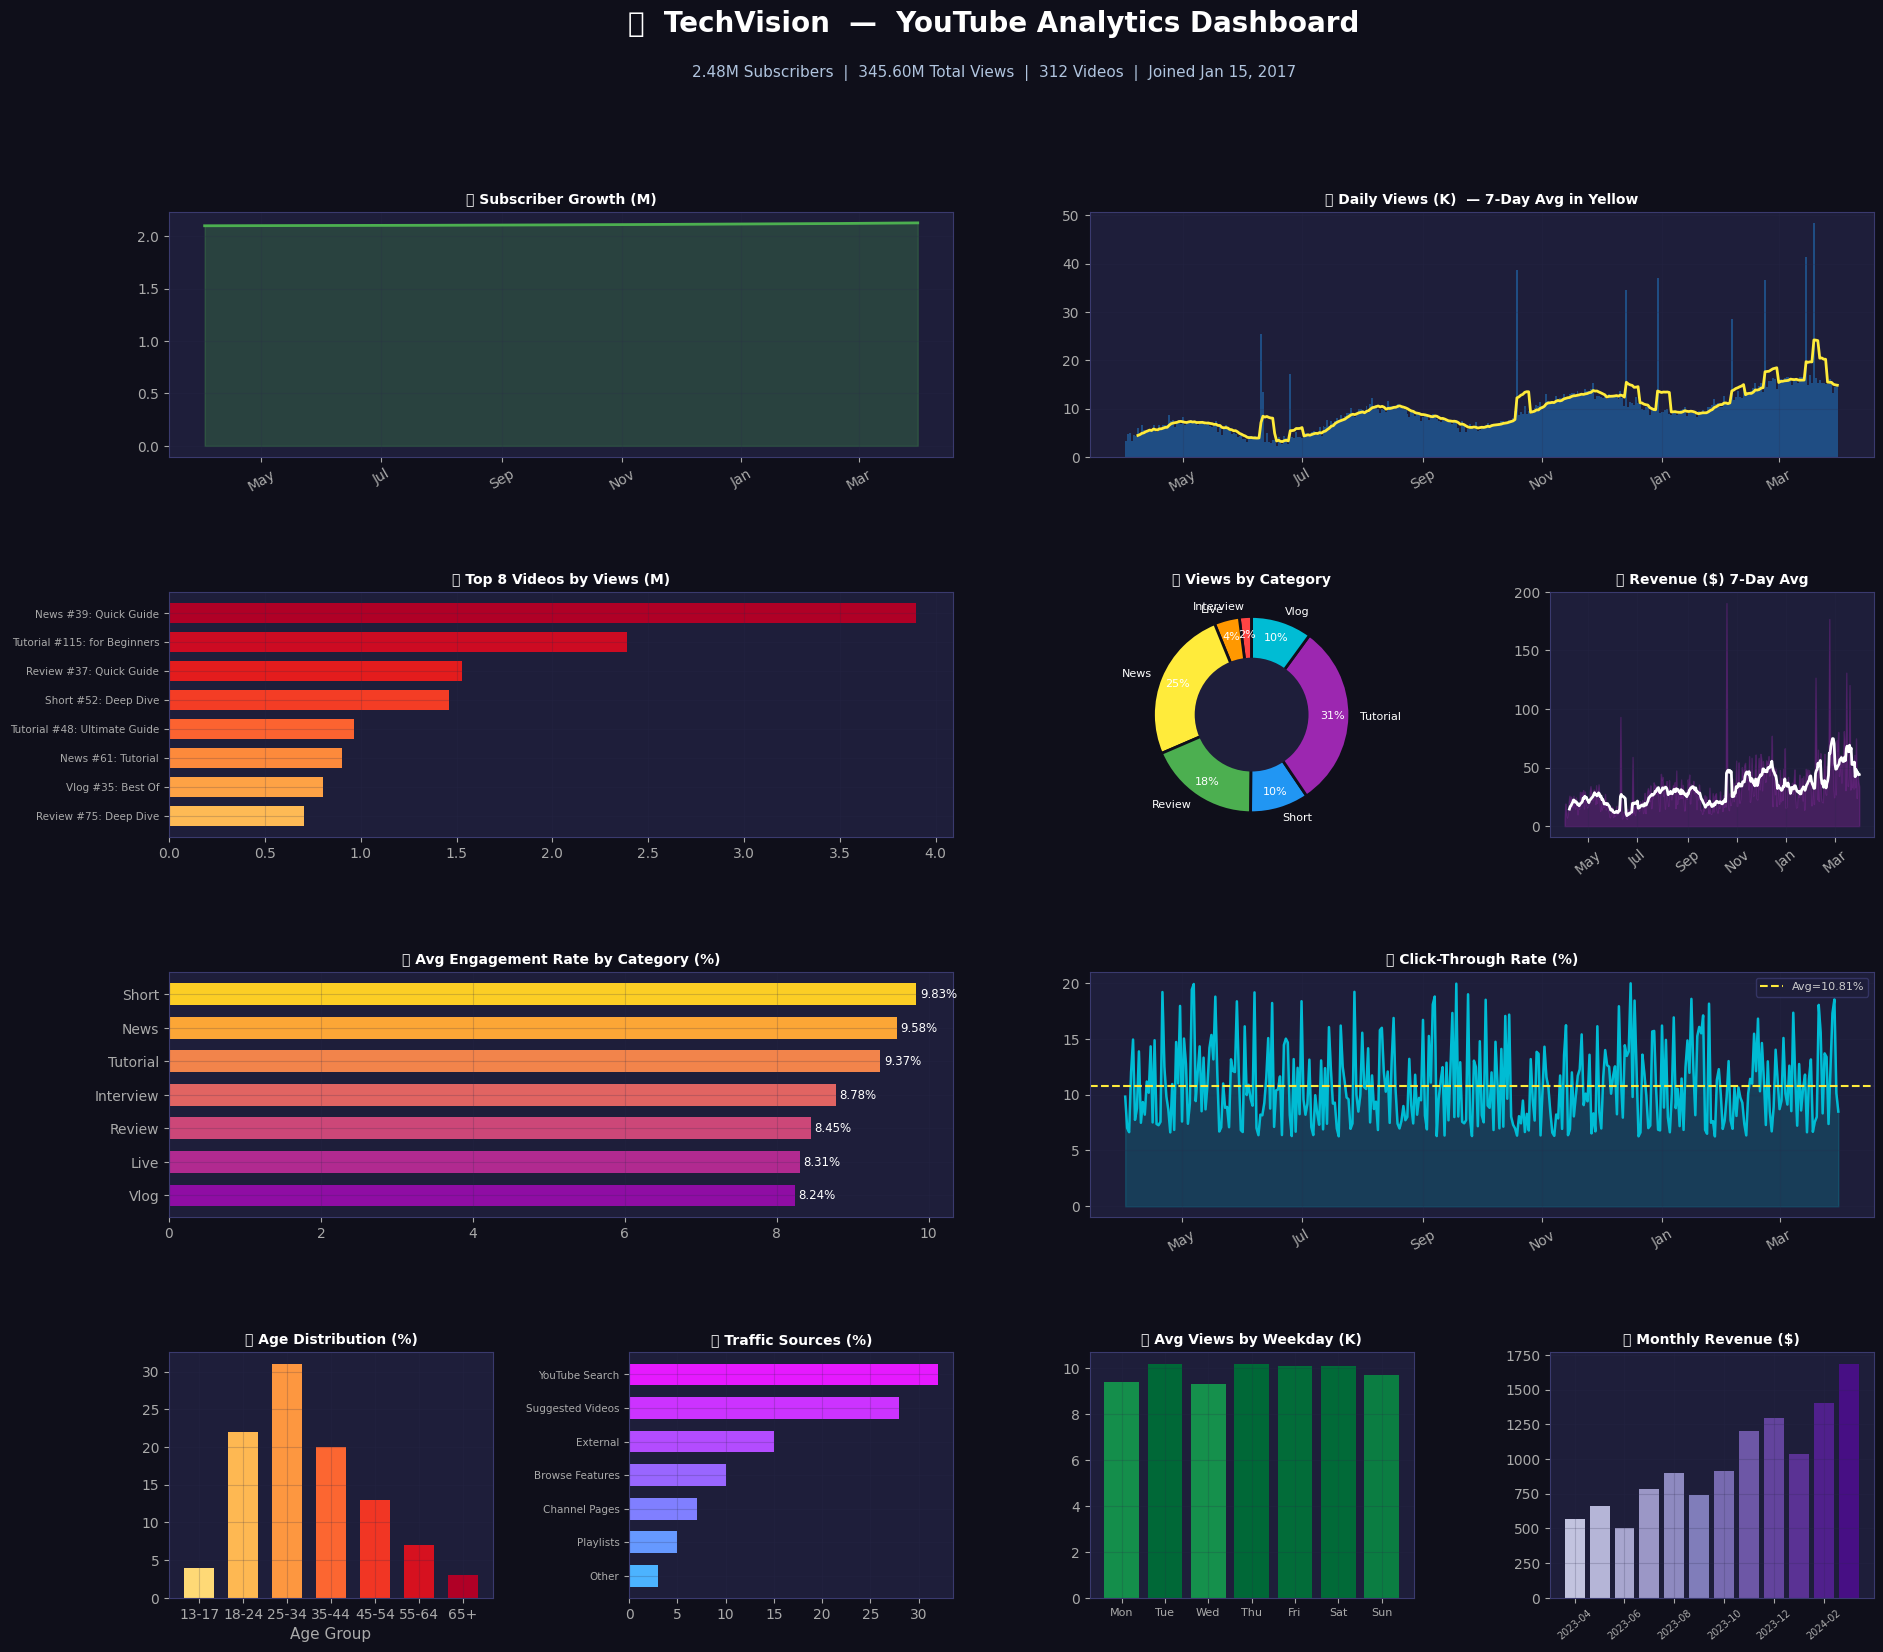

💾  Saved: yt_11_dashboard.png


In [21]:
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(DARK_BG)
gs  = gridspec.GridSpec(4, 4, figure=fig,
                        hspace=0.55, wspace=0.42)

fig.text(0.5, 0.98,
         f'🎬  {channel["name"]}  —  YouTube Analytics Dashboard',
         ha='center', fontsize=20, fontweight='bold', color='white')
fig.text(0.5, 0.955,
         f'{fmt(channel["subscribers"])} Subscribers  |  '
         f'{fmt(channel["total_views"])} Total Views  |  '
         f'{channel["total_videos"]} Videos  |  '
         f'Joined {channel["joined_date"]}',
         ha='center', fontsize=11, color='#B0C4DE')

def dax(ax, title):
    ax.set_facecolor(CARD_BG)
    for sp in ax.spines.values(): sp.set_edgecolor('#3a3a6e')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='#aaa')
    ax.xaxis.label.set_color('#aaa')
    ax.yaxis.label.set_color('#aaa')
    ax.grid(True, alpha=0.2)

# P1 — Subscriber growth
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(ts['date'], ts['subscribers']/1e6,
                 alpha=0.25, color=C_SUBS)
ax1.plot(ts['date'], ts['subscribers']/1e6, color=C_SUBS, lw=2)
dax(ax1, '📈 Subscriber Growth (M)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.tick_params(axis='x', rotation=30)

# P2 — Daily views
ax2 = fig.add_subplot(gs[0, 2:])
ax2.bar(ts['date'], ts['views']/1e3, color=C_VIEWS,
        alpha=0.4, width=1)
ax2.plot(ts['date'], ts['views_7d']/1e3, color='#FFEB3B', lw=2)
dax(ax2, '👁️ Daily Views (K)  — 7-Day Avg in Yellow')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.tick_params(axis='x', rotation=30)

# P3 — Top 8 videos
ax3 = fig.add_subplot(gs[1, :2])
t8  = videos.nlargest(8, 'views')
clrs8 = plt.cm.YlOrRd(np.linspace(0.35, 0.9, 8))
ax3.barh(range(8), t8['views'][::-1].values/1e6,
         color=clrs8, edgecolor='none', height=0.7)
ax3.set_yticks(range(8))
ax3.set_yticklabels([t[:30]+'…' if len(t)>30 else t
                     for t in t8['title'][::-1].values],
                    fontsize=7.5)
dax(ax3, '🏆 Top 8 Videos by Views (M)')

# P4 — Category pie
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(CARD_BG)
cat_v = videos.groupby('category')['views'].sum()
ax4.pie(cat_v.values, labels=cat_v.index,
        colors=PALETTE[:len(cat_v)],
        autopct='%1.0f%%', startangle=90,
        wedgeprops={'edgecolor':DARK_BG,'lw':2},
        textprops={'color':'white','fontsize':8}, pctdistance=0.82)
ctr2 = plt.Circle((0,0), 0.58, fc=CARD_BG)
ax4.add_artist(ctr2)
ax4.set_title('📂 Views by Category', color='white',
              fontsize=10, fontweight='bold')

# P5 — Revenue trend
ax5 = fig.add_subplot(gs[1, 3])
ax5.fill_between(ts['date'], ts['revenue_usd'],
                 alpha=0.3, color=C_REV)
ax5.plot(ts['date'], ts['rev_7d'], color='white', lw=2)
dax(ax5, '💰 Revenue ($) 7-Day Avg')
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax5.tick_params(axis='x', rotation=40)

# P6 — Engagement rate by category
ax6     = fig.add_subplot(gs[2, :2])
eng_cat = videos.groupby('category')['engagement_rate'].mean().sort_values()
clrs_e  = plt.cm.plasma(np.linspace(0.3, 0.9, len(eng_cat)))
ax6.barh(eng_cat.index, eng_cat.values, color=clrs_e,
         edgecolor='none', height=0.65)
for i, v in enumerate(eng_cat.values):
    ax6.text(v+0.05, i, f'{v:.2f}%',
             va='center', fontsize=8.5, color='white')
dax(ax6, '💬 Avg Engagement Rate by Category (%)')

# P7 — CTR daily
ax7 = fig.add_subplot(gs[2, 2:])
ax7.plot(ts['date'], ts['ctr_pct'], color=C_ENGAGE, lw=1.8)
ax7.fill_between(ts['date'], ts['ctr_pct'],
                 alpha=0.2, color=C_ENGAGE)
ax7.axhline(ts['ctr_pct'].mean(), color='#FFEB3B',
            lw=1.5, linestyle='--',
            label=f'Avg={ts["ctr_pct"].mean():.2f}%')
dax(ax7, '🖱️ Click-Through Rate (%)')
ax7.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax7.tick_params(axis='x', rotation=30)
ax7.legend(fontsize=8)

# P8 — Age group
ax8 = fig.add_subplot(gs[3, 0])
clrs_ag = plt.cm.YlOrRd(np.linspace(0.25, 0.9, len(age_df)))
ax8.bar(age_df['group'], age_df['pct'], color=clrs_ag,
        edgecolor='none', width=0.7)
dax(ax8, '👥 Age Distribution (%)')
ax8.set_xlabel('Age Group')

# P9 — Traffic sources
ax9     = fig.add_subplot(gs[3, 1])
traf_s2 = traf_df.sort_values('pct', ascending=True)
clrs_t2 = plt.cm.cool(np.linspace(0.3, 0.9, len(traf_s2)))
ax9.barh(traf_s2['source'], traf_s2['pct'],
         color=clrs_t2, edgecolor='none', height=0.65)
dax(ax9, '🚦 Traffic Sources (%)')
ax9.tick_params(axis='y', labelsize=7.5)

# P10 — Weekday performance
ax10    = fig.add_subplot(gs[3, 2])
wd_v    = ts.groupby('weekday')['views'].mean().reindex(wday_o)
clrs_w  = plt.cm.RdYlGn(wd_v.values / wd_v.max())
ax10.bar(range(7), wd_v.values/1e3, color=clrs_w, edgecolor='none')
ax10.set_xticks(range(7))
ax10.set_xticklabels([d[:3] for d in wday_o], fontsize=8)
dax(ax10, '📅 Avg Views by Weekday (K)')

# P11 — Monthly revenue
ax11    = fig.add_subplot(gs[3, 3])
mr      = ts.groupby('month')['revenue_usd'].sum().reset_index()
clrs_mr = plt.cm.Purples(np.linspace(0.35, 0.95, len(mr)))
ax11.bar(range(len(mr)), mr['revenue_usd'], color=clrs_mr, edgecolor='none')
ax11.set_xticks(range(0, len(mr), 2))
ax11.set_xticklabels(mr['month'].iloc[::2], fontsize=7, rotation=40)
dax(ax11, '💵 Monthly Revenue ($)')

plt.savefig('yt_11_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('💾  Saved: yt_11_dashboard.png')

---
## Step 14 — Insights & Recommendations

In [22]:
# ── Auto-generate insights from data ──────────────────────────
best_cat      = cat_stats['avg_views'].idxmax()
best_cat_eng  = cat_stats['avg_engage'].idxmax()
best_hour     = videos.groupby('pub_hour')['views'].mean().idxmax()
best_weekday  = videos.groupby('pub_weekday')['views'].mean().idxmax()
best_dur      = videos.groupby('dur_band')['views'].mean().idxmax()
top_vid       = videos.nlargest(1,'views').iloc[0]
avg_eng_over  = videos['engagement_rate'].mean()
avg_ctr_v     = videos['ctr_pct'].mean()
rev_total     = videos['revenue_usd'].sum()
growth_rate   = (ts['subscribers'].iloc[-1] - ts['subscribers'].iloc[0]) / \
                 ts['subscribers'].iloc[0] * 100

print('=' * 65)
print('     🎬  YOUTUBE CHANNEL — INSIGHTS & SUMMARY')
print('=' * 65)
print(f'\n📊  CHANNEL OVERVIEW')
print(f'   Name            : {channel["name"]}')
print(f'   Subscribers     : {fmt(channel["subscribers"])}')
print(f'   Total Views     : {fmt(channel["total_views"])}')
print(f'   Total Videos    : {channel["total_videos"]}')
print(f'   Annual Revenue  : ${ts["revenue_usd"].sum():,.0f}')
print(f'   Sub Growth (YoY): {growth_rate:+.1f}%')

print(f'\n📈  PERFORMANCE METRICS')
print(f'   Avg Views/Video      : {fmt(int(videos["views"].mean()))}')
print(f'   Avg Engagement Rate  : {avg_eng_over:.2f}%')
print(f'   Avg CTR              : {avg_ctr_v:.2f}%')
print(f'   Avg Avg View Duration: {ts["avg_view_dur"].mean():.0f}s '
      f'({ts["avg_view_dur"].mean()/60:.1f} min)')
print(f'   Avg RPM              : ${videos["rpm"].mean():.2f}')

print(f'\n🏆  TOP PERFORMERS')
print(f'   Best Video        : {top_vid["title"][:50]}')
print(f'   Best Video Views  : {fmt(top_vid["views"])}')
print(f'   Best Category (views) : {best_cat}')
print(f'   Best Category (engage): {best_cat_eng}')

print(f'\n💡  RECOMMENDATIONS')
print(f'   ✅  Publish at {best_hour:02d}:00 for maximum views')
print(f'   ✅  Best publishing day: {best_weekday}')
print(f'   ✅  Optimal video length: {best_dur} videos get most views')
print(f'   ✅  Focus on "{best_cat}" content — highest avg views')
print(f'   ✅  Prioritize "{best_cat_eng}" for audience engagement')
print(f'   ✅  YouTube Search (32%) is top traffic source — optimize SEO')
print(f'   ✅  Mobile (62%) dominates — use vertical thumbnails')
print(f'   ✅  Top audience: 25-34 age group — tailor content accordingly')

print(f'\n📂  SAVED PLOT FILES')
for f in ['yt_01_kpi_cards.png','yt_02_subscriber_growth.png',
          'yt_03_video_performance.png','yt_04_category_breakdown.png',
          'yt_05_views_watchtime.png','yt_06_engagement.png',
          'yt_07_revenue.png','yt_08_demographics.png',
          'yt_09_posting_time.png','yt_10_correlation.png',
          'yt_11_dashboard.png']:
    print(f'   • {f}')
print('=' * 65)

     🎬  YOUTUBE CHANNEL — INSIGHTS & SUMMARY

📊  CHANNEL OVERVIEW
   Name            : TechVision
   Subscribers     : 2.48M
   Total Views     : 345.60M
   Total Videos    : 312
   Annual Revenue  : $11,686
   Sub Growth (YoY): +1.3%

📈  PERFORMANCE METRICS
   Avg Views/Video      : 160.5K
   Avg Engagement Rate  : 9.07%
   Avg CTR              : 8.35%
   Avg Avg View Duration: 295s (4.9 min)
   Avg RPM              : $3.71

🏆  TOP PERFORMERS
   Best Video        : News #39: Quick Guide
   Best Video Views  : 3.90M
   Best Category (views) : News
   Best Category (engage): Short

💡  RECOMMENDATIONS
   ✅  Publish at 00:00 for maximum views
   ✅  Best publishing day: Monday
   ✅  Optimal video length: 20-60 min videos get most views
   ✅  Focus on "News" content — highest avg views
   ✅  Prioritize "Short" for audience engagement
   ✅  YouTube Search (32%) is top traffic source — optimize SEO
   ✅  Mobile (62%) dominates — use vertical thumbnails
   ✅  Top audience: 25-34 age group — ta

---
### 📝 Section Reference

| Plot File | Section | Key Insight |
|-----------|---------|-------------|
| `yt_01_kpi_cards.png` | Channel Overview | 8 KPI cards with all headline metrics |
| `yt_02_subscriber_growth.png` | Subscriber Analysis | Growth curve, gained/lost, monthly net, weekday pattern |
| `yt_03_video_performance.png` | Video Performance | Top 15 by views, views vs engagement scatter |
| `yt_04_category_breakdown.png` | Category Analysis | 6-panel category comparison across all key metrics |
| `yt_05_views_watchtime.png` | Views & Watch Time | 3-panel: daily views, watch hours, CTR + avg duration |
| `yt_06_engagement.png` | Engagement Deep Dive | 6-panel: distribution, likes vs views, CTR, comments |
| `yt_07_revenue.png` | Revenue Analysis | Daily/monthly revenue, by category, RPM distribution |
| `yt_08_demographics.png` | Audience Demographics | Age, gender, device, countries, traffic sources |
| `yt_09_posting_time.png` | Optimal Posting | By hour, by weekday, video duration vs views |
| `yt_10_correlation.png` | Correlation Analysis | Heatmap + Pearson/Spearman significance tests |
| `yt_11_dashboard.png` | Summary Dashboard | 11-panel dark-theme all-in-one executive dashboard |

> 💡 **Next Steps:** Pair this notebook with `youtube_dashboard.py` (Streamlit) for an interactive version of all these charts.